In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
from scipy.signal import savgol_filter
from pathlib import Path
from scipy.stats import linregress

# store plastic slip rates and temperatures
data = []
maxout = 1000

# plot function for stress and pile-up dislocations
def plot_stress_bfield(npt = 300, file=None, cutoff=100.):
    xpts = np.linspace(0.0, dsl.lx, npt)
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i], YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i])
    extent = (0.0, dsl.lx, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu], dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.08)
    #cbar.set_label(r"$\sigma_{12}$ (MPa)")
    cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:], dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(0., dsl.by[npu:].max())
    ax2.invert_yaxis()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    ax2.set_position([
        pos1.x0,
        pos2.y0,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b_y \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()

def find_h5_files(directory: str | Path, recursive: bool = False) -> list[Path]:
    """
    Find all .h5 files in a directory.

    Parameters
    ----------
    directory : str | Path
        Directory to search.
    recursive : bool, optional
        If True, search recursively in subdirectories.

    Returns
    -------
    list[Path]
        Sorted list of .h5 files.
    """
    path = Path(directory)

    if not path.is_dir():
        raise NotADirectoryError(f"Not a directory: {path}")

    pattern = "**/*.h5" if recursive else "*.h5"

    return sorted(path.glob(pattern))

Data file with H=10.0, L=0.1, T=1000.0, tau0=100.0, n=24


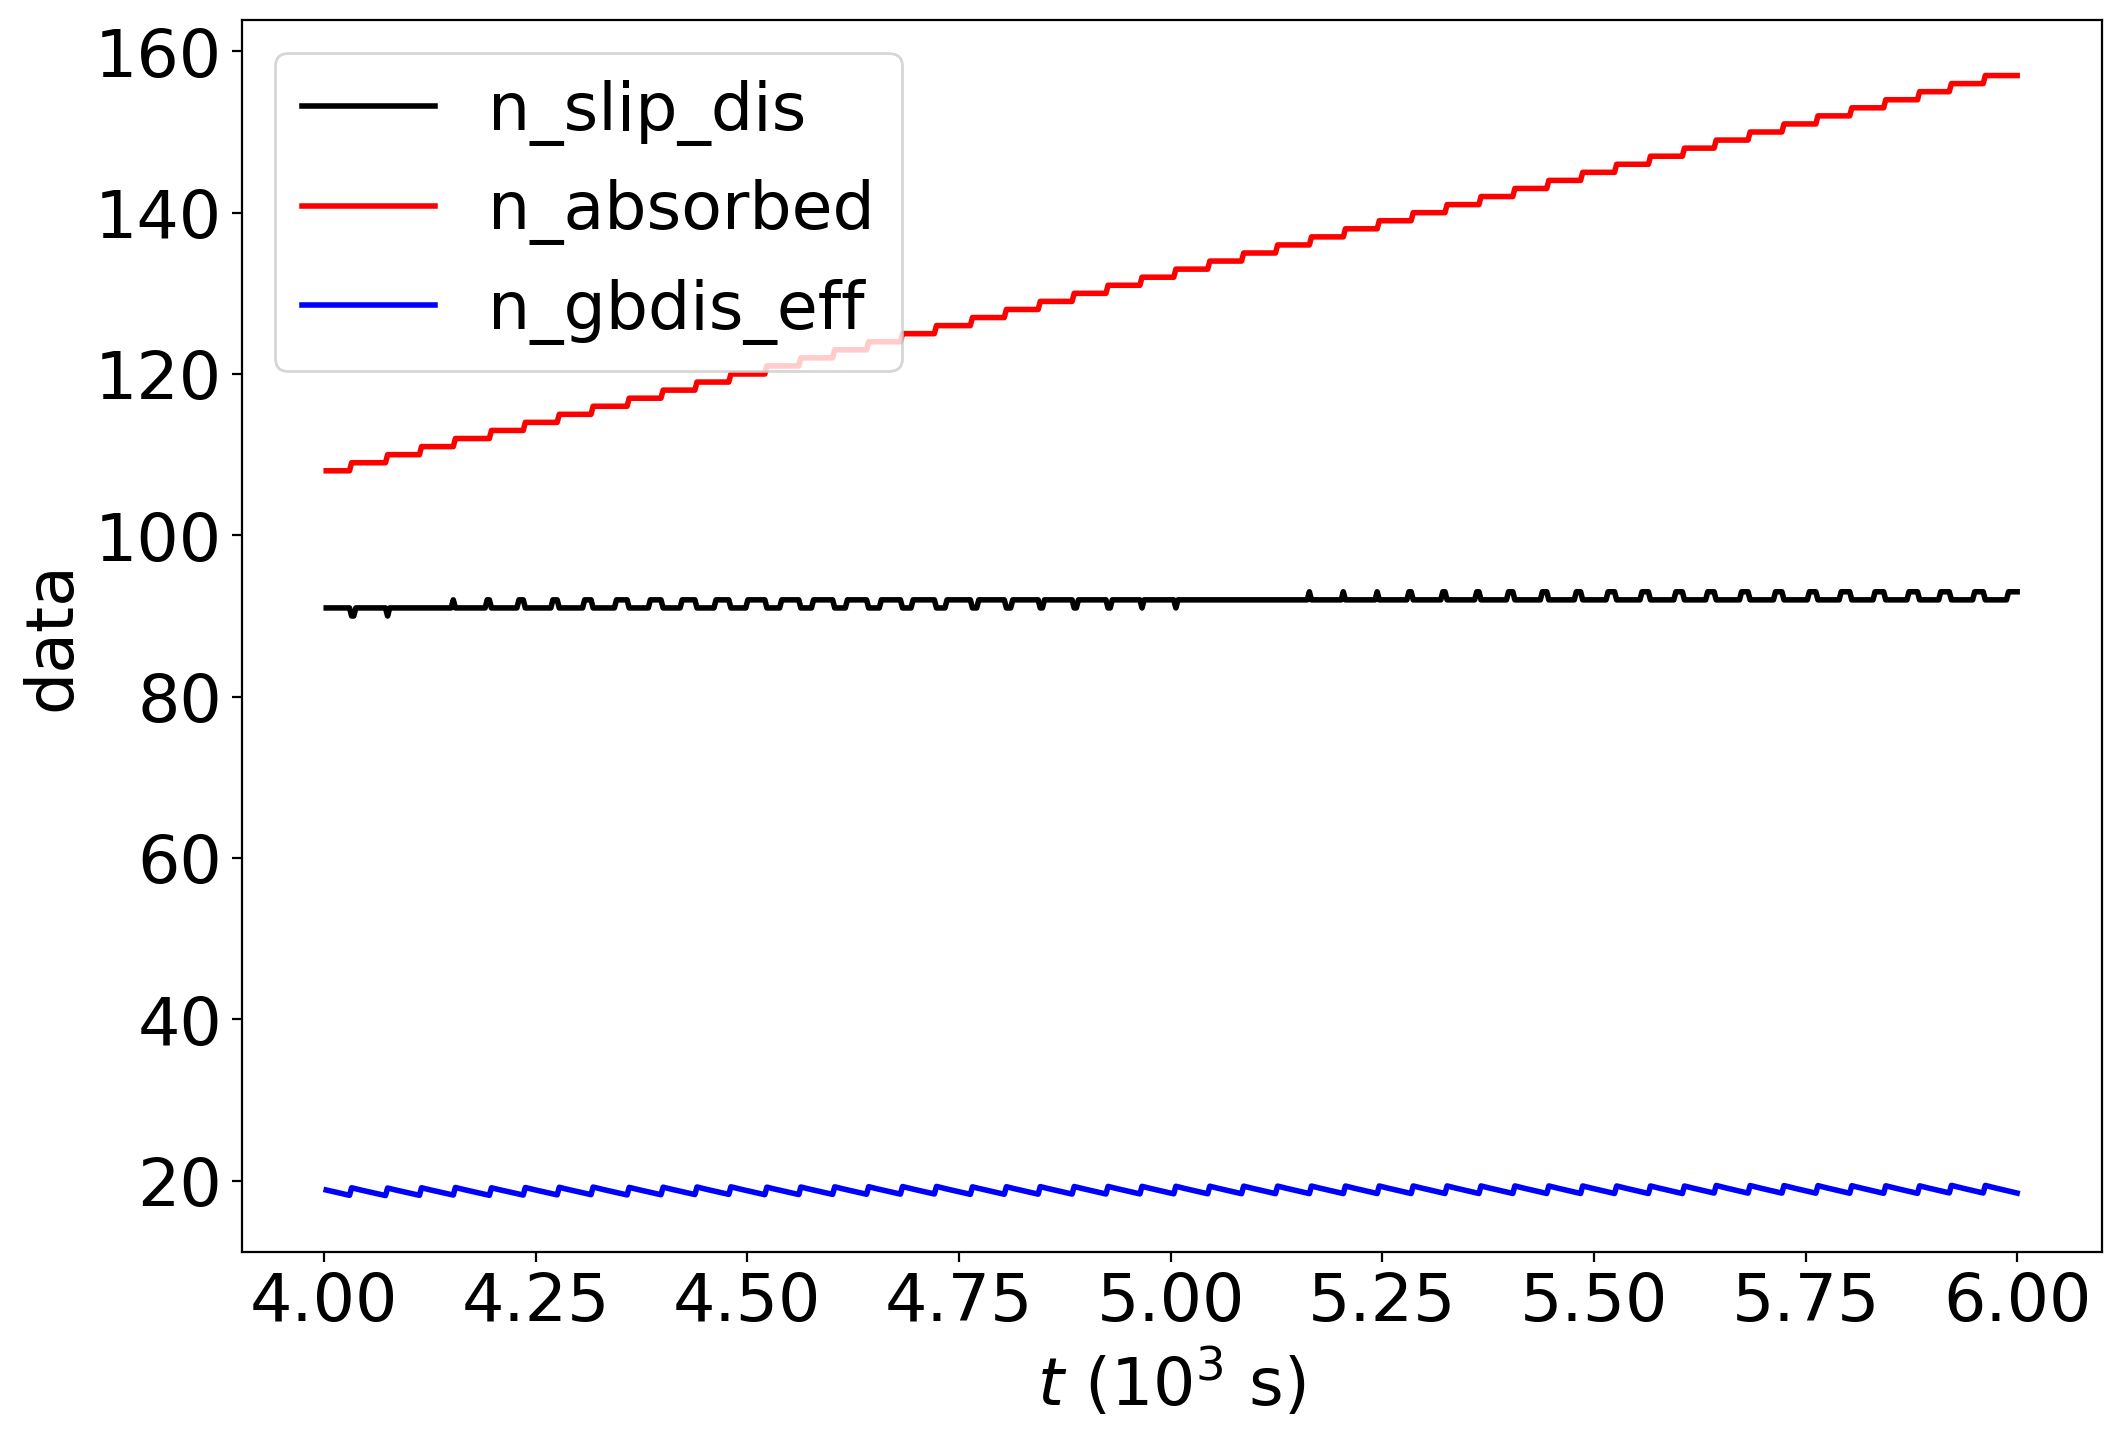

** Max. time step = 2441.406249999999, Median: 2060.2140037507393
Av. slip rate: 6.345213888067e-11, Nslip: 92.34, Ngb_eff: 18.89230803234151
Data file with H=10.0, L=0.1, T=800.0, tau0=100.0, n=24


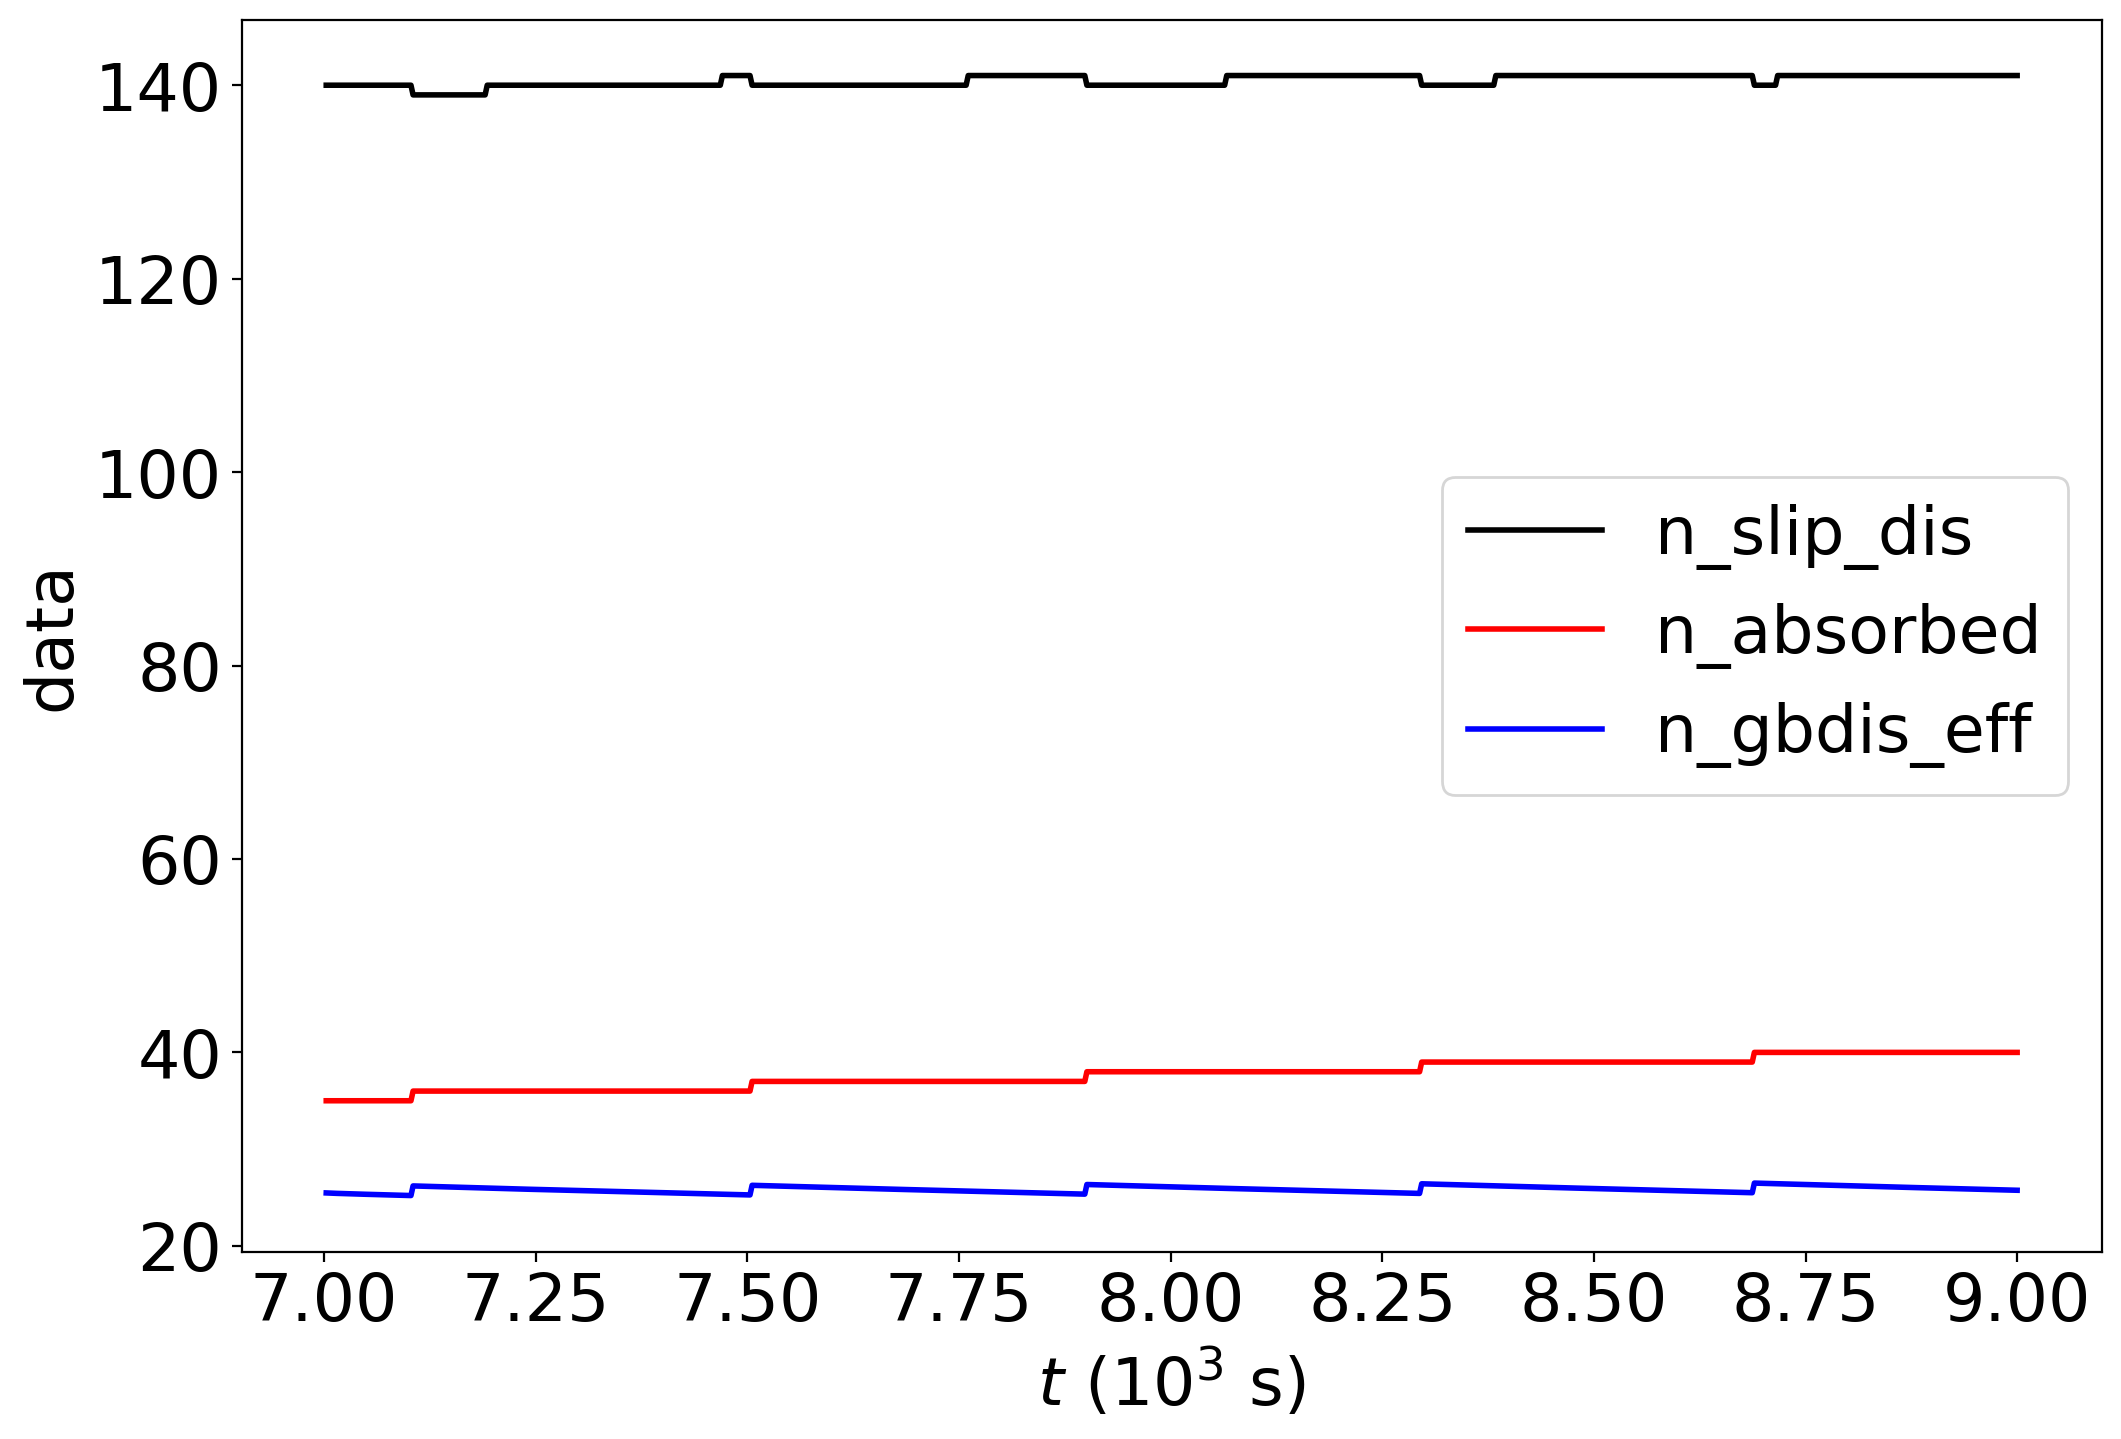

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 6.9520295446636765e-12, Nslip: 141.0, Ngb_eff: 26.033235032848328
Data file with H=10.0, L=0.1, T=900.0, tau0=100.0, n=24


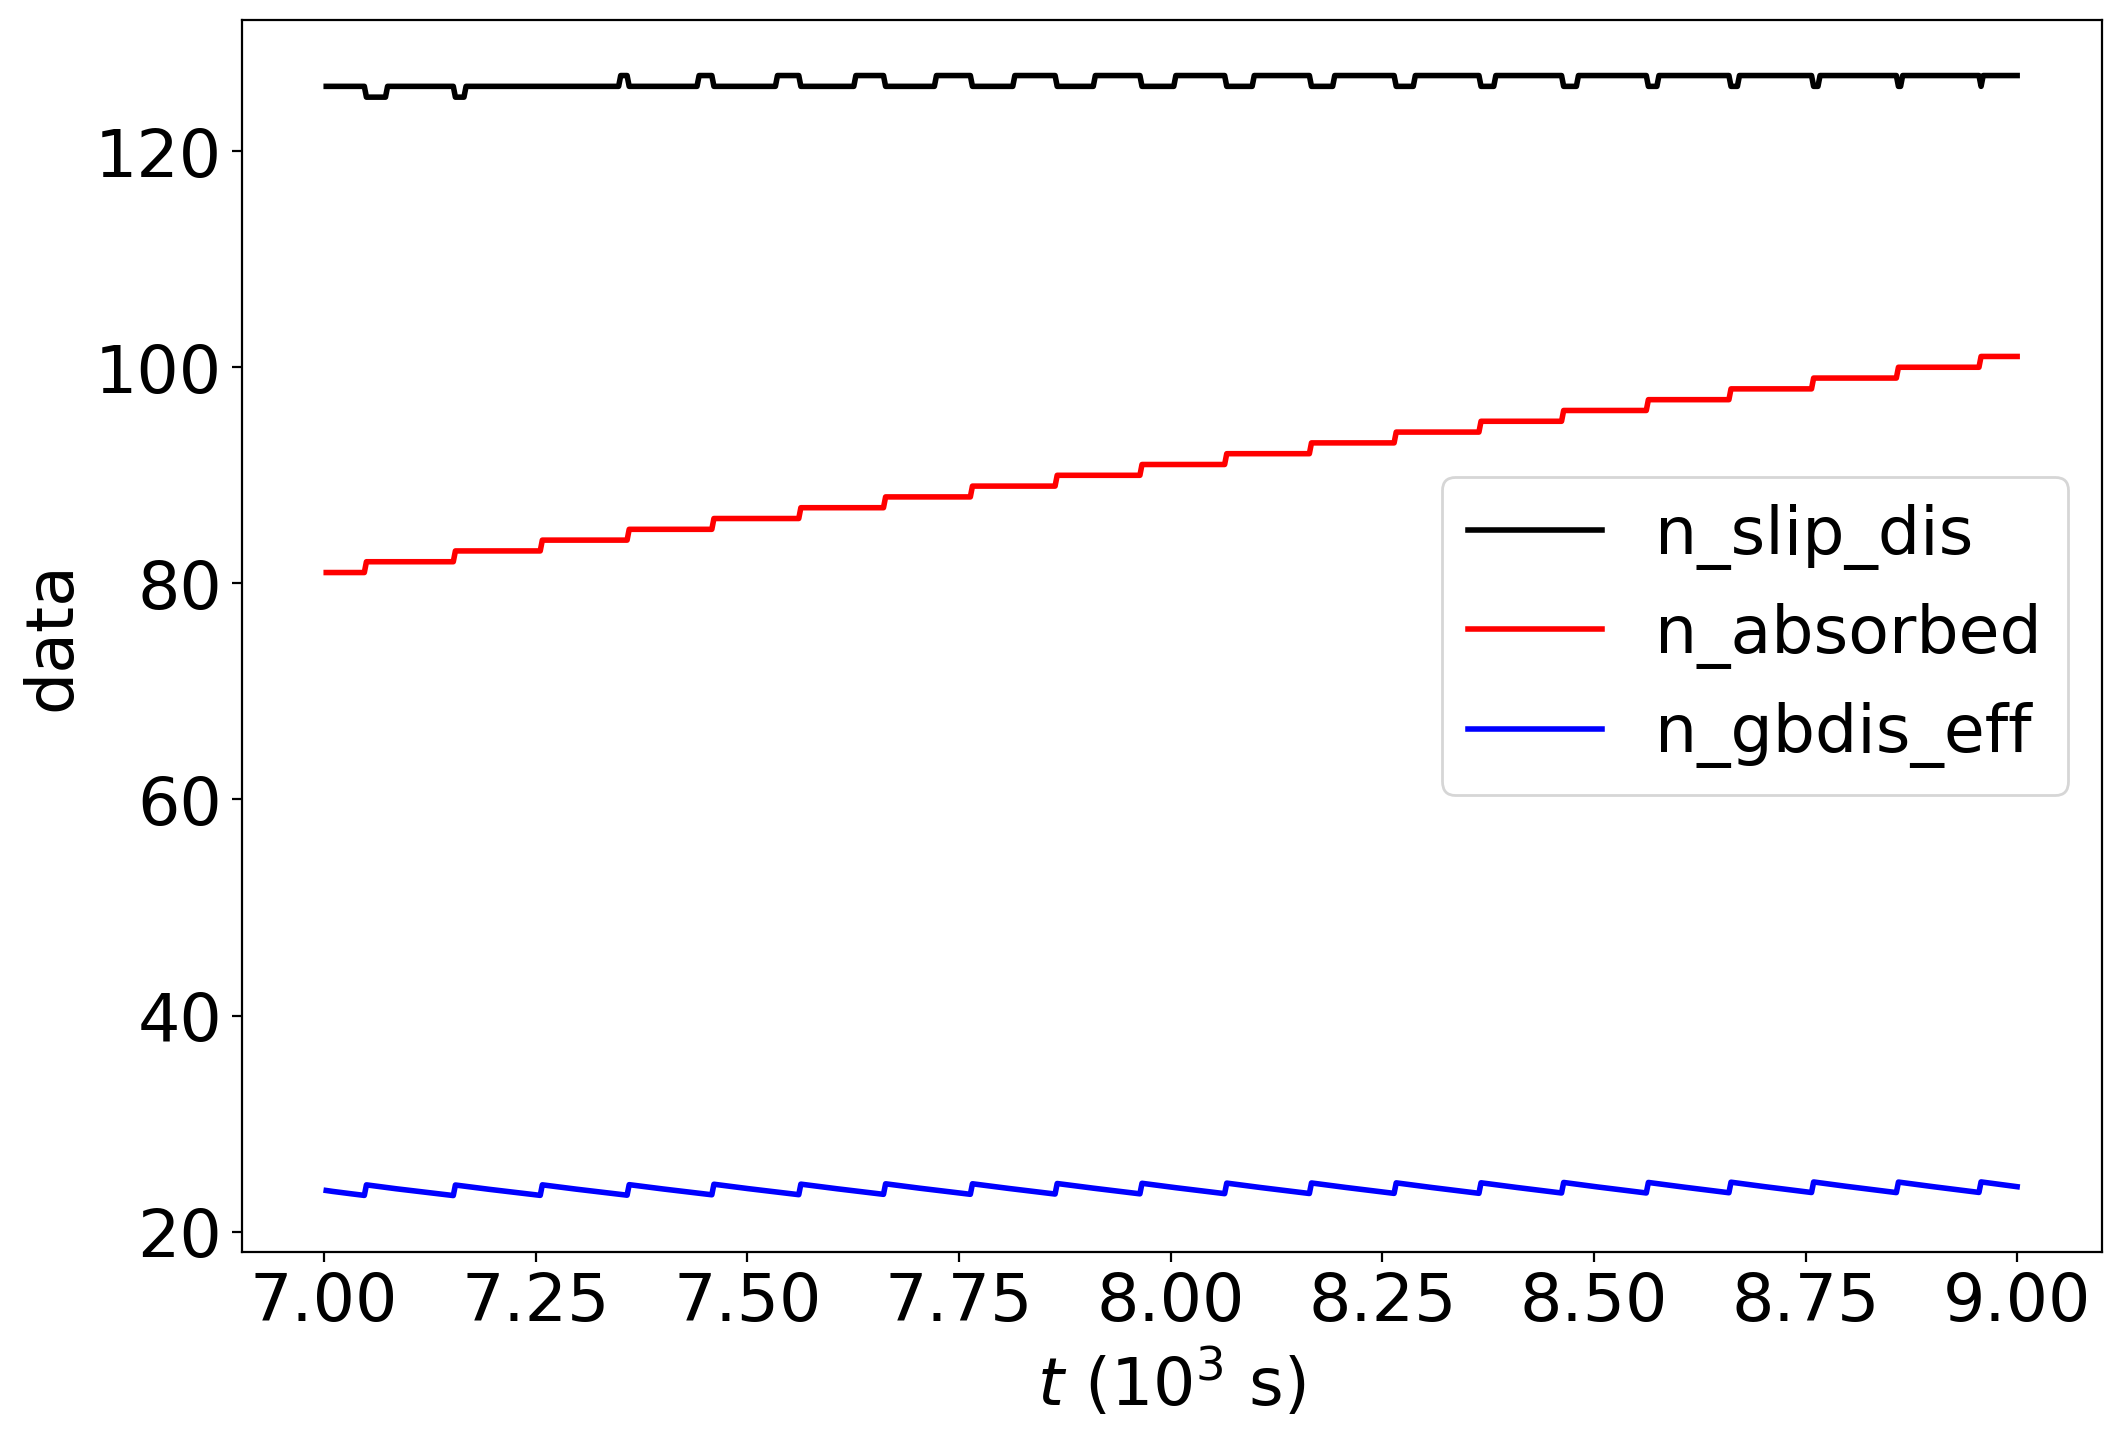

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.6082520641657025e-11, Nslip: 126.94, Ngb_eff: 24.13189185857428
Data file with H=10.0, L=0.1, T=1000.0, tau0=10.0, n=24


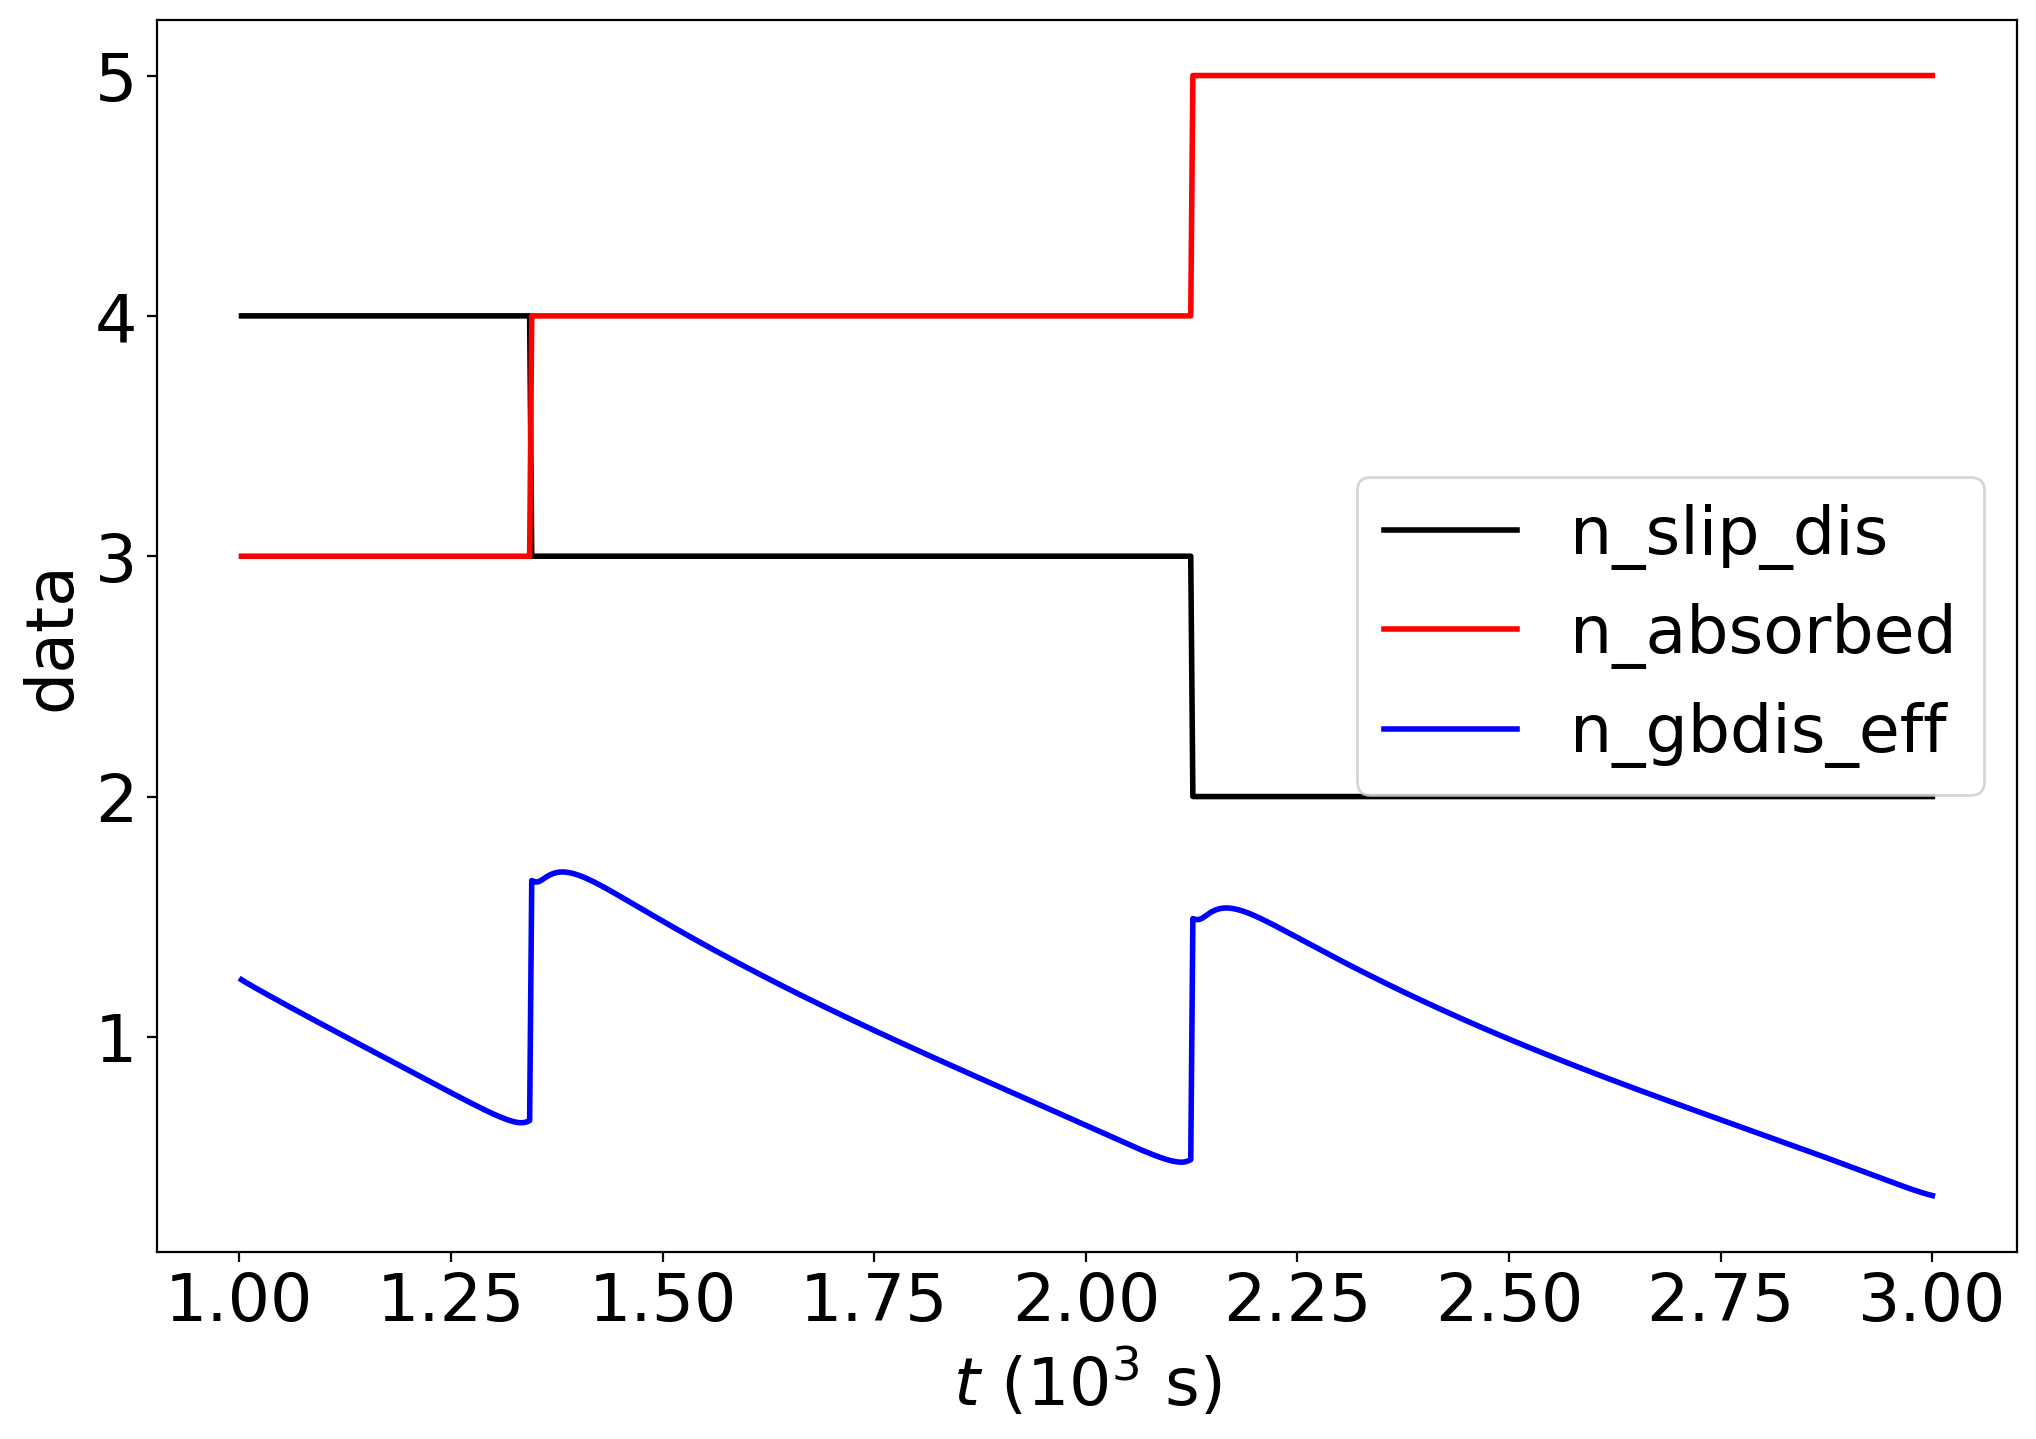

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.645885446668218e-13, Nslip: 2.0, Ngb_eff: 0.49475260132033627
Data file with H=10.0, L=0.1, T=800.0, tau0=10.0, n=24


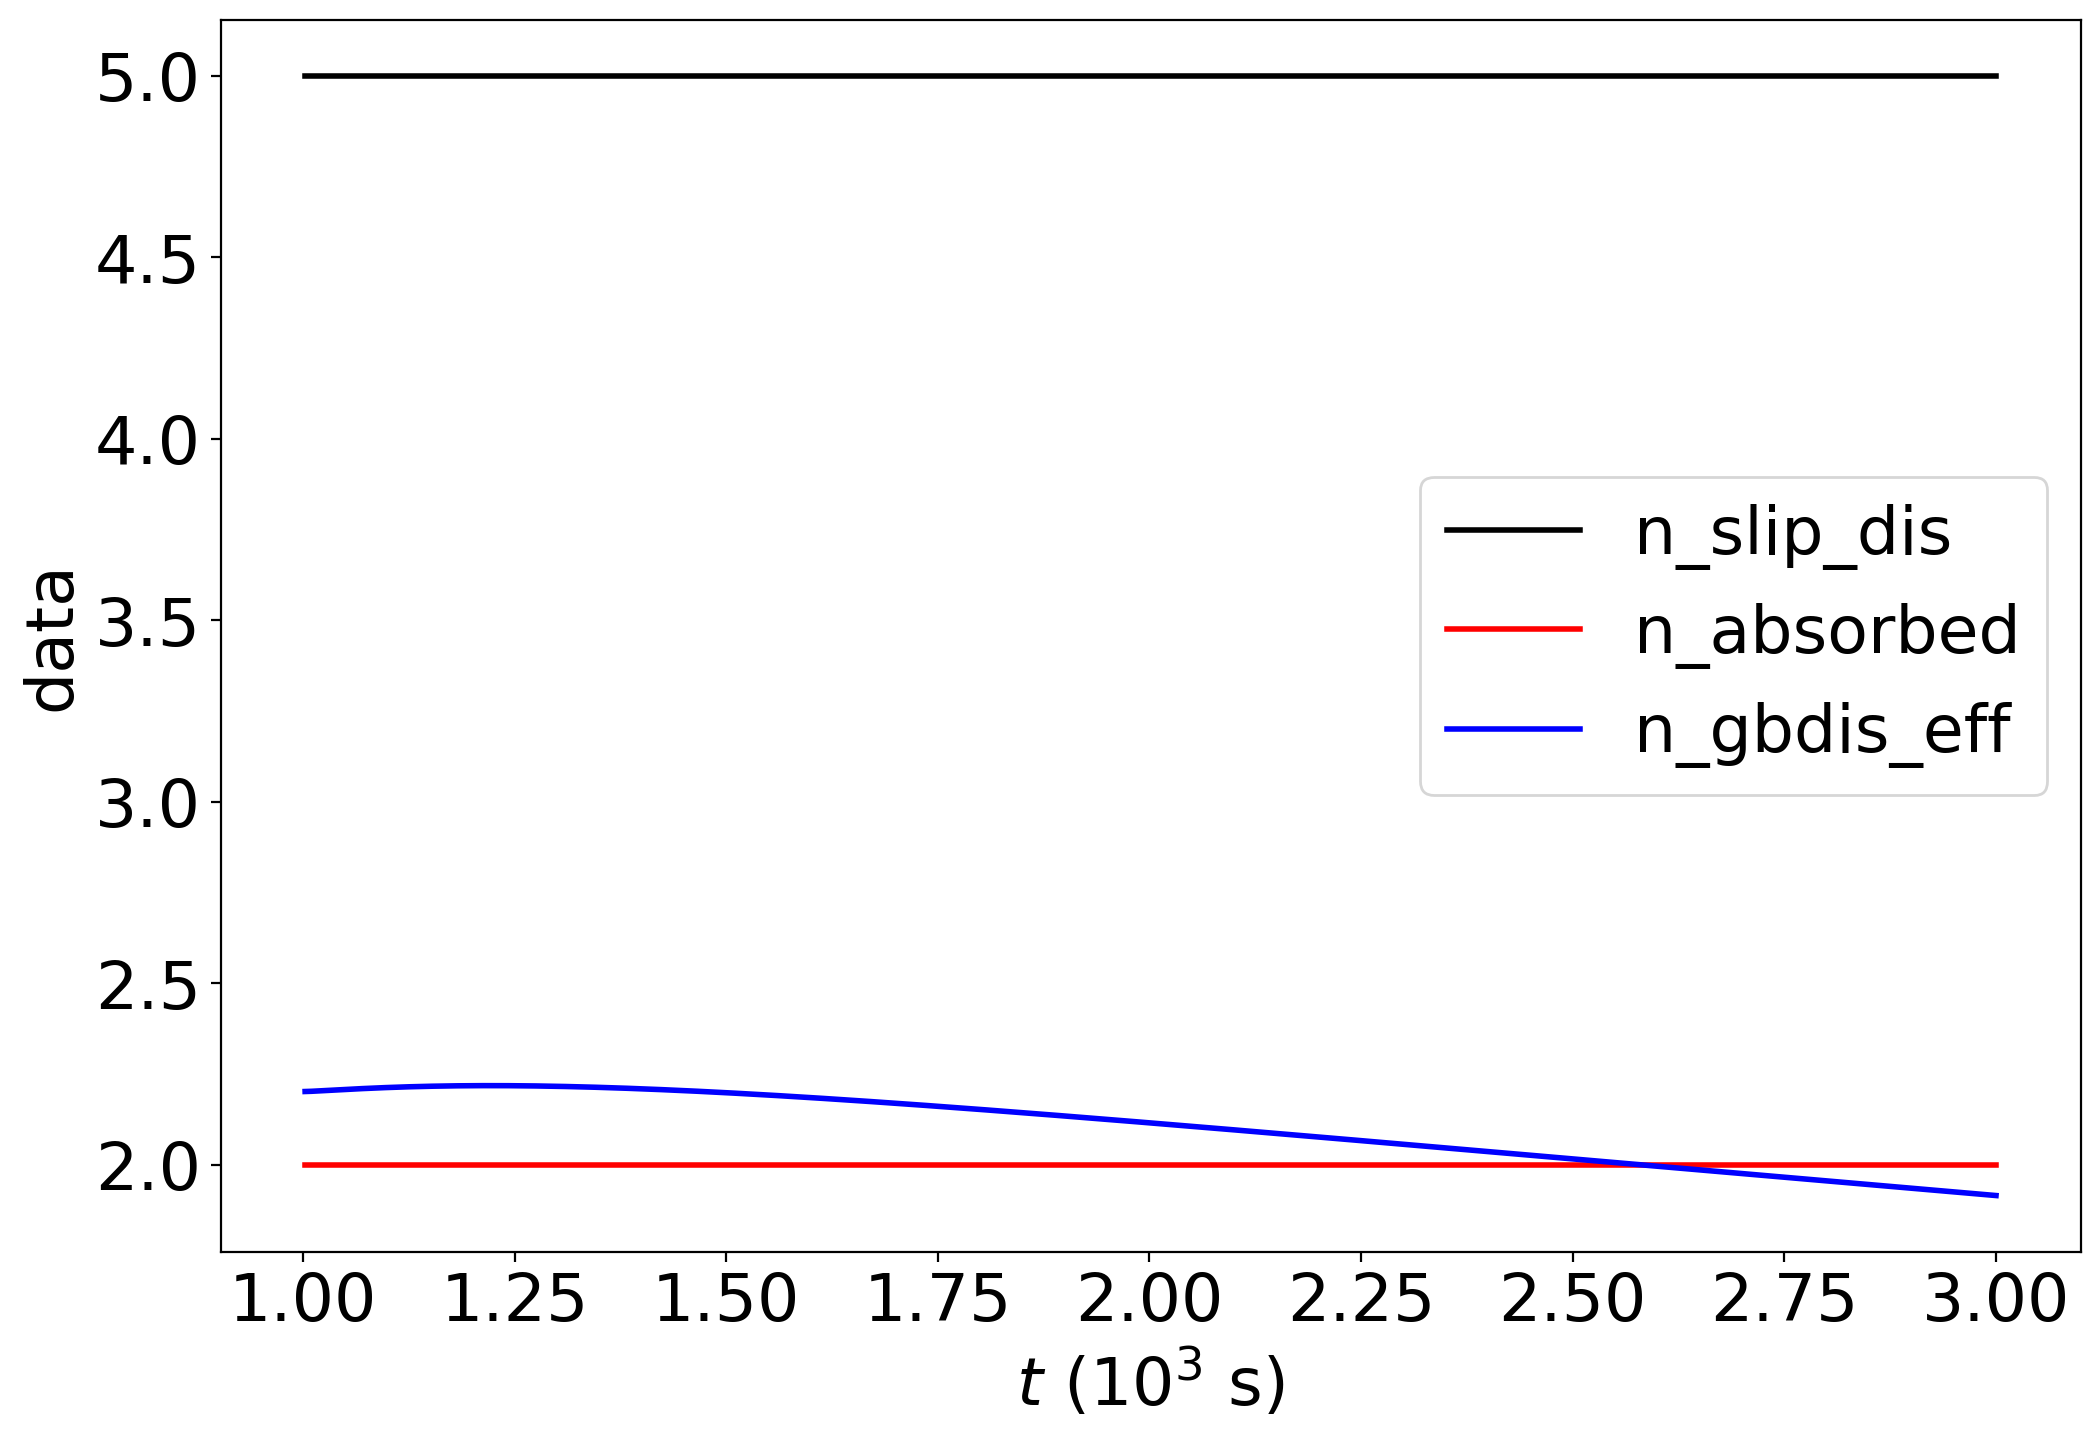

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 2.1615564534727134e-14, Nslip: 5.0, Ngb_eff: 1.9398871037851364
Data file with H=10.0, L=0.1, T=900.0, tau0=10.0, n=24


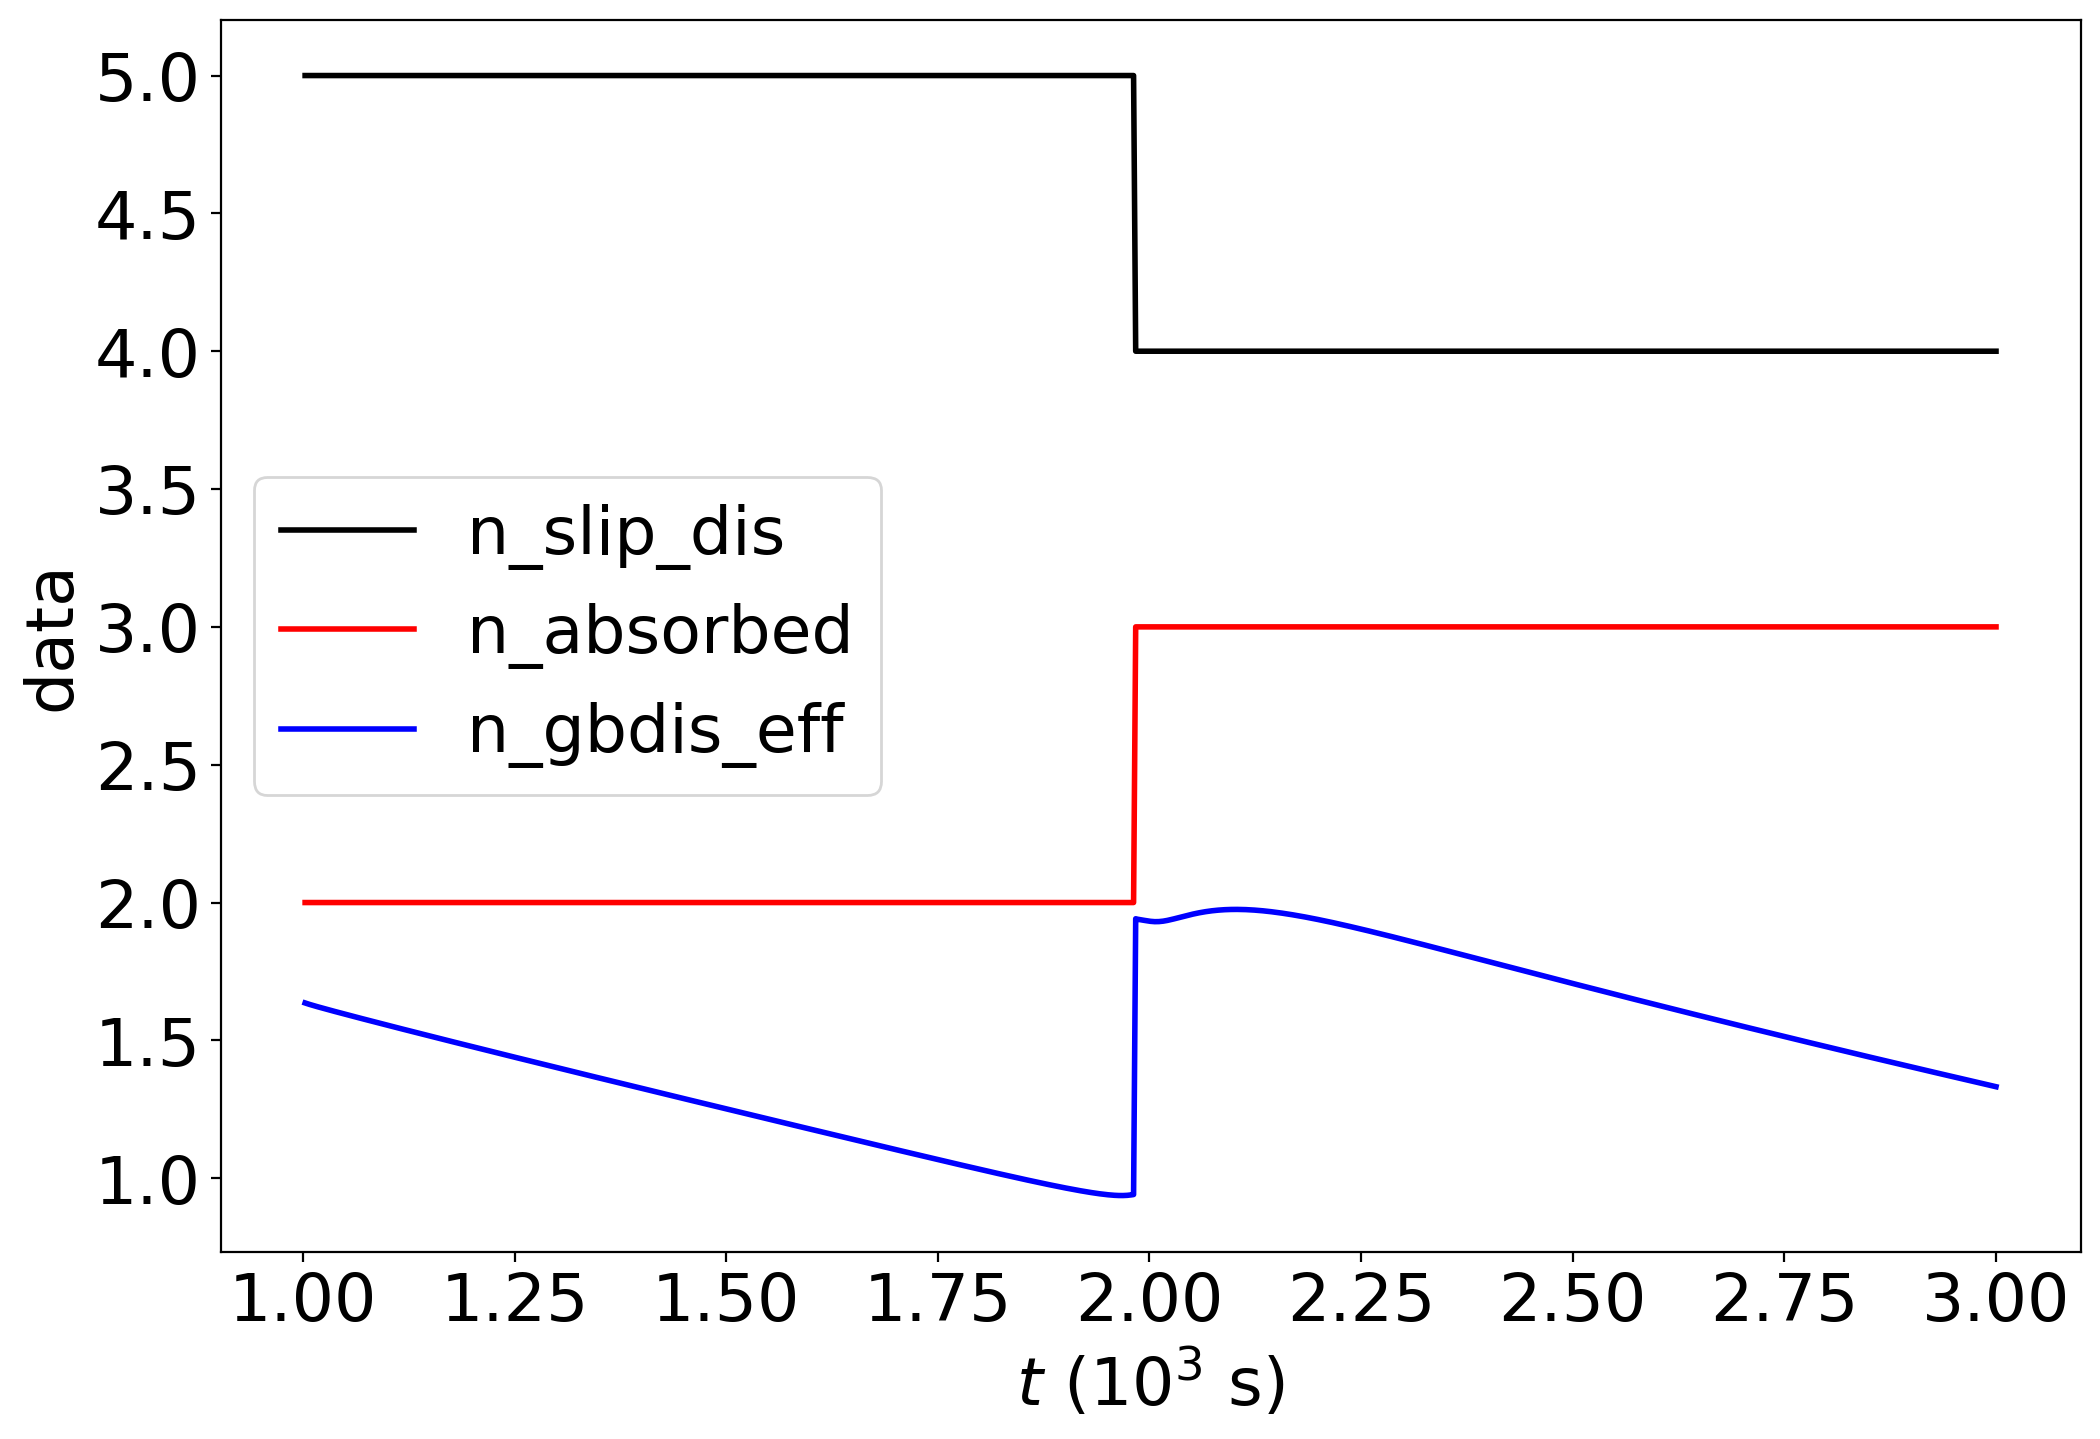

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.6102497028214208e-13, Nslip: 4.0, Ngb_eff: 1.42142054030513
Data file with H=10.0, L=0.1, T=1000.0, tau0=125.0, n=24


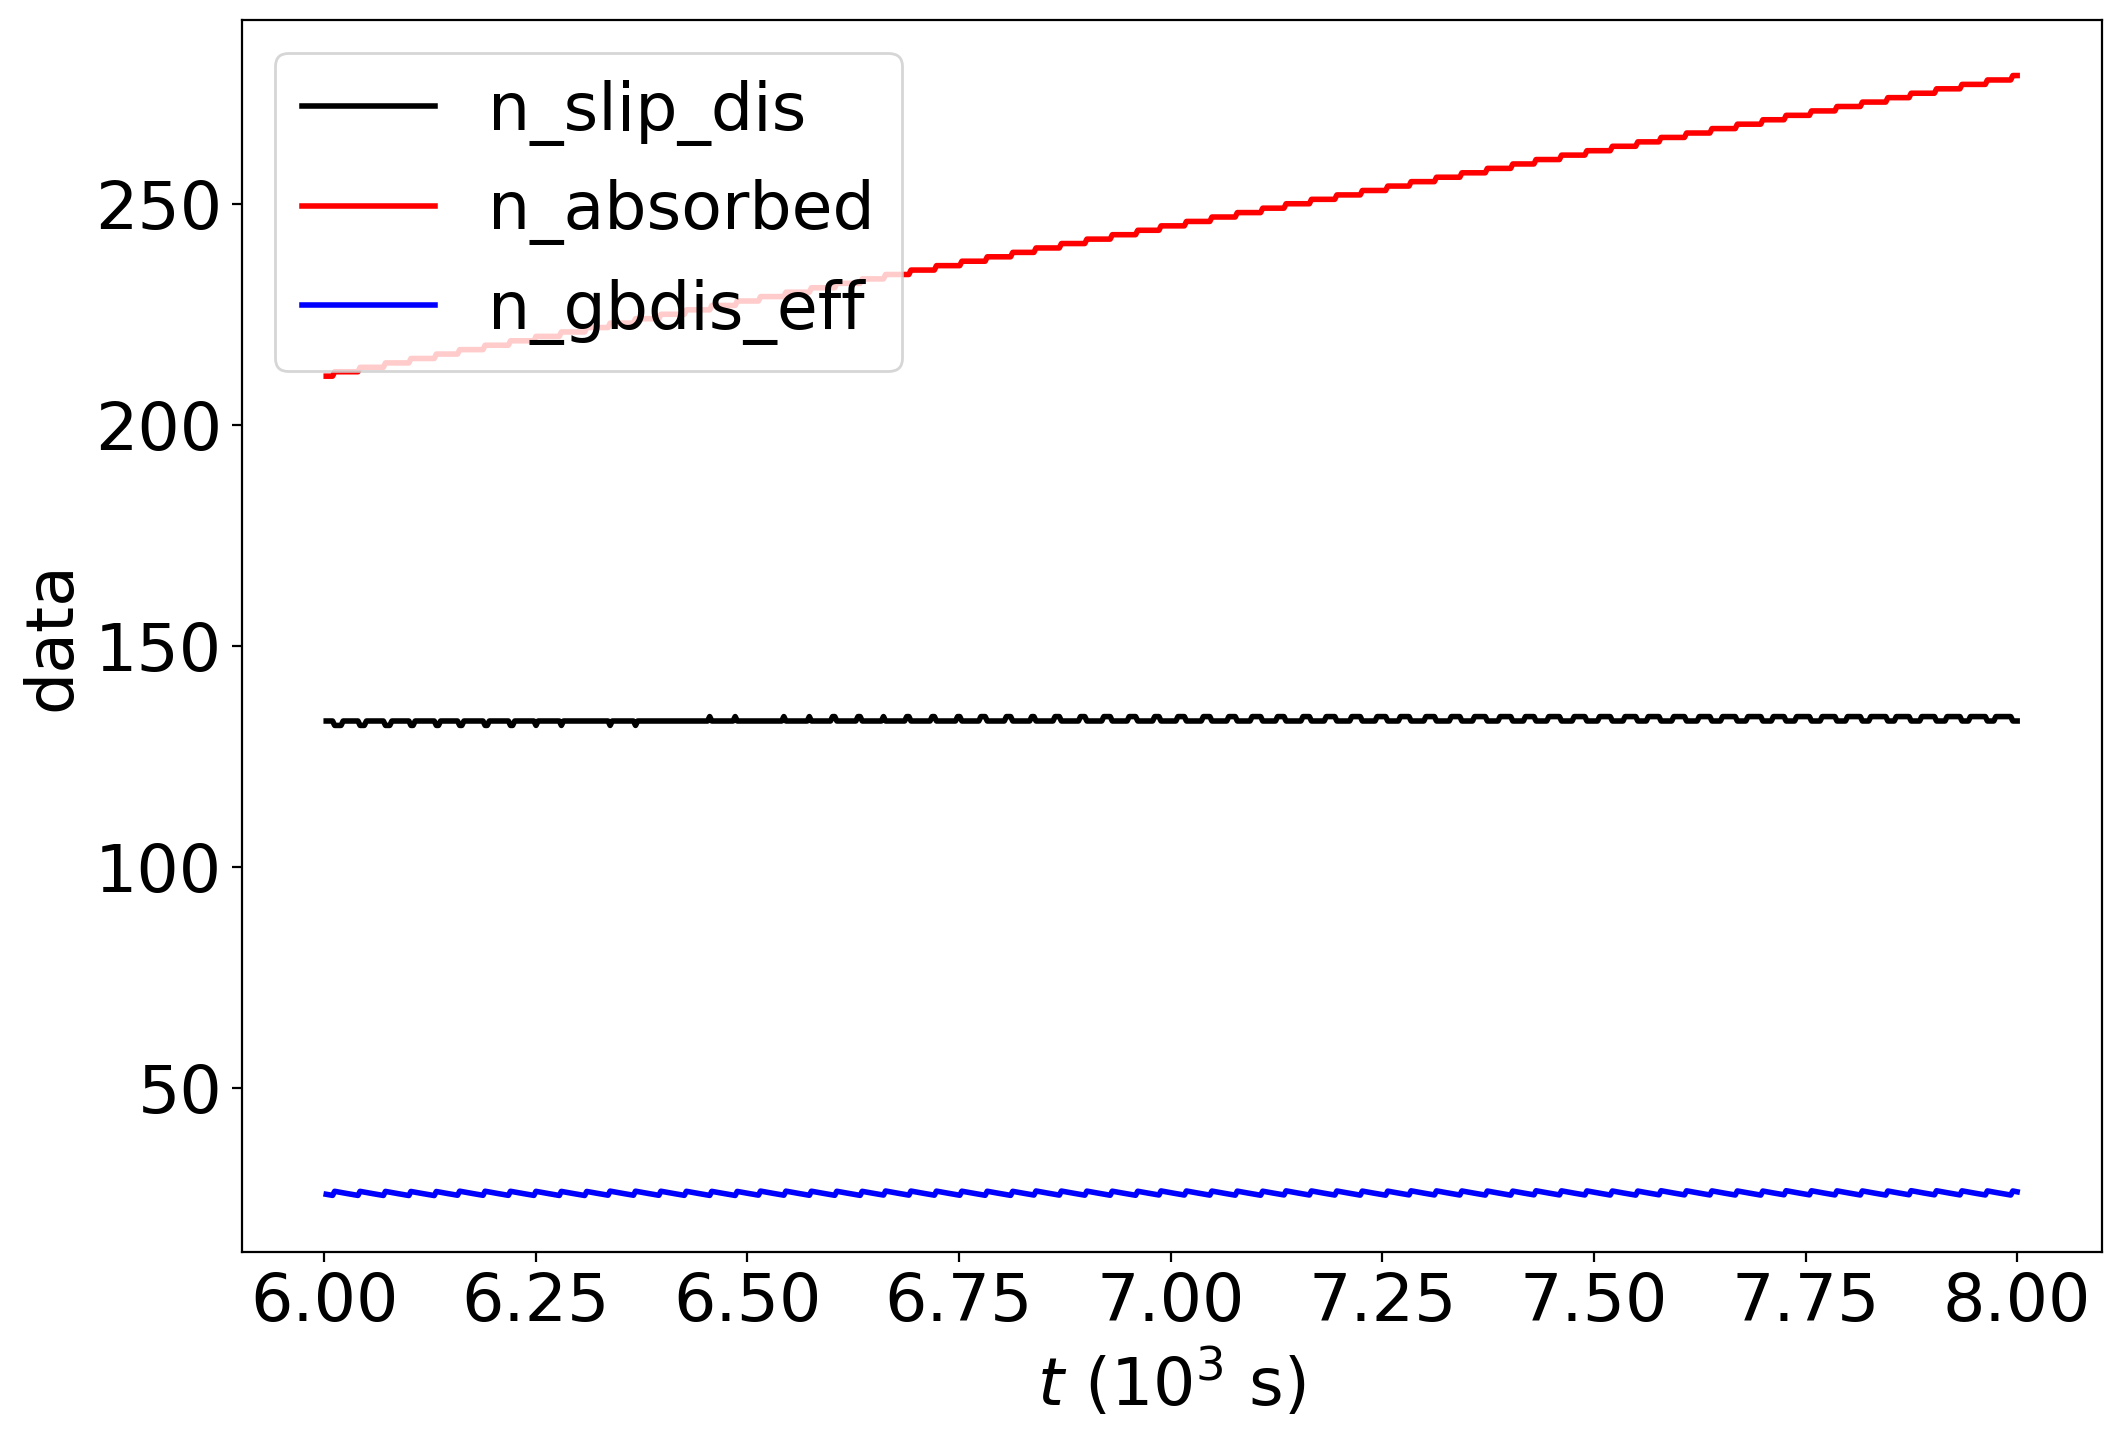

** Max. time step = 1696.6640527288698, Median: 1394.5675757149074
Av. slip rate: 8.510401341695232e-11, Nslip: 133.61, Ngb_eff: 26.254203256573575
Data file with H=10.0, L=0.1, T=800.0, tau0=125.0, n=24


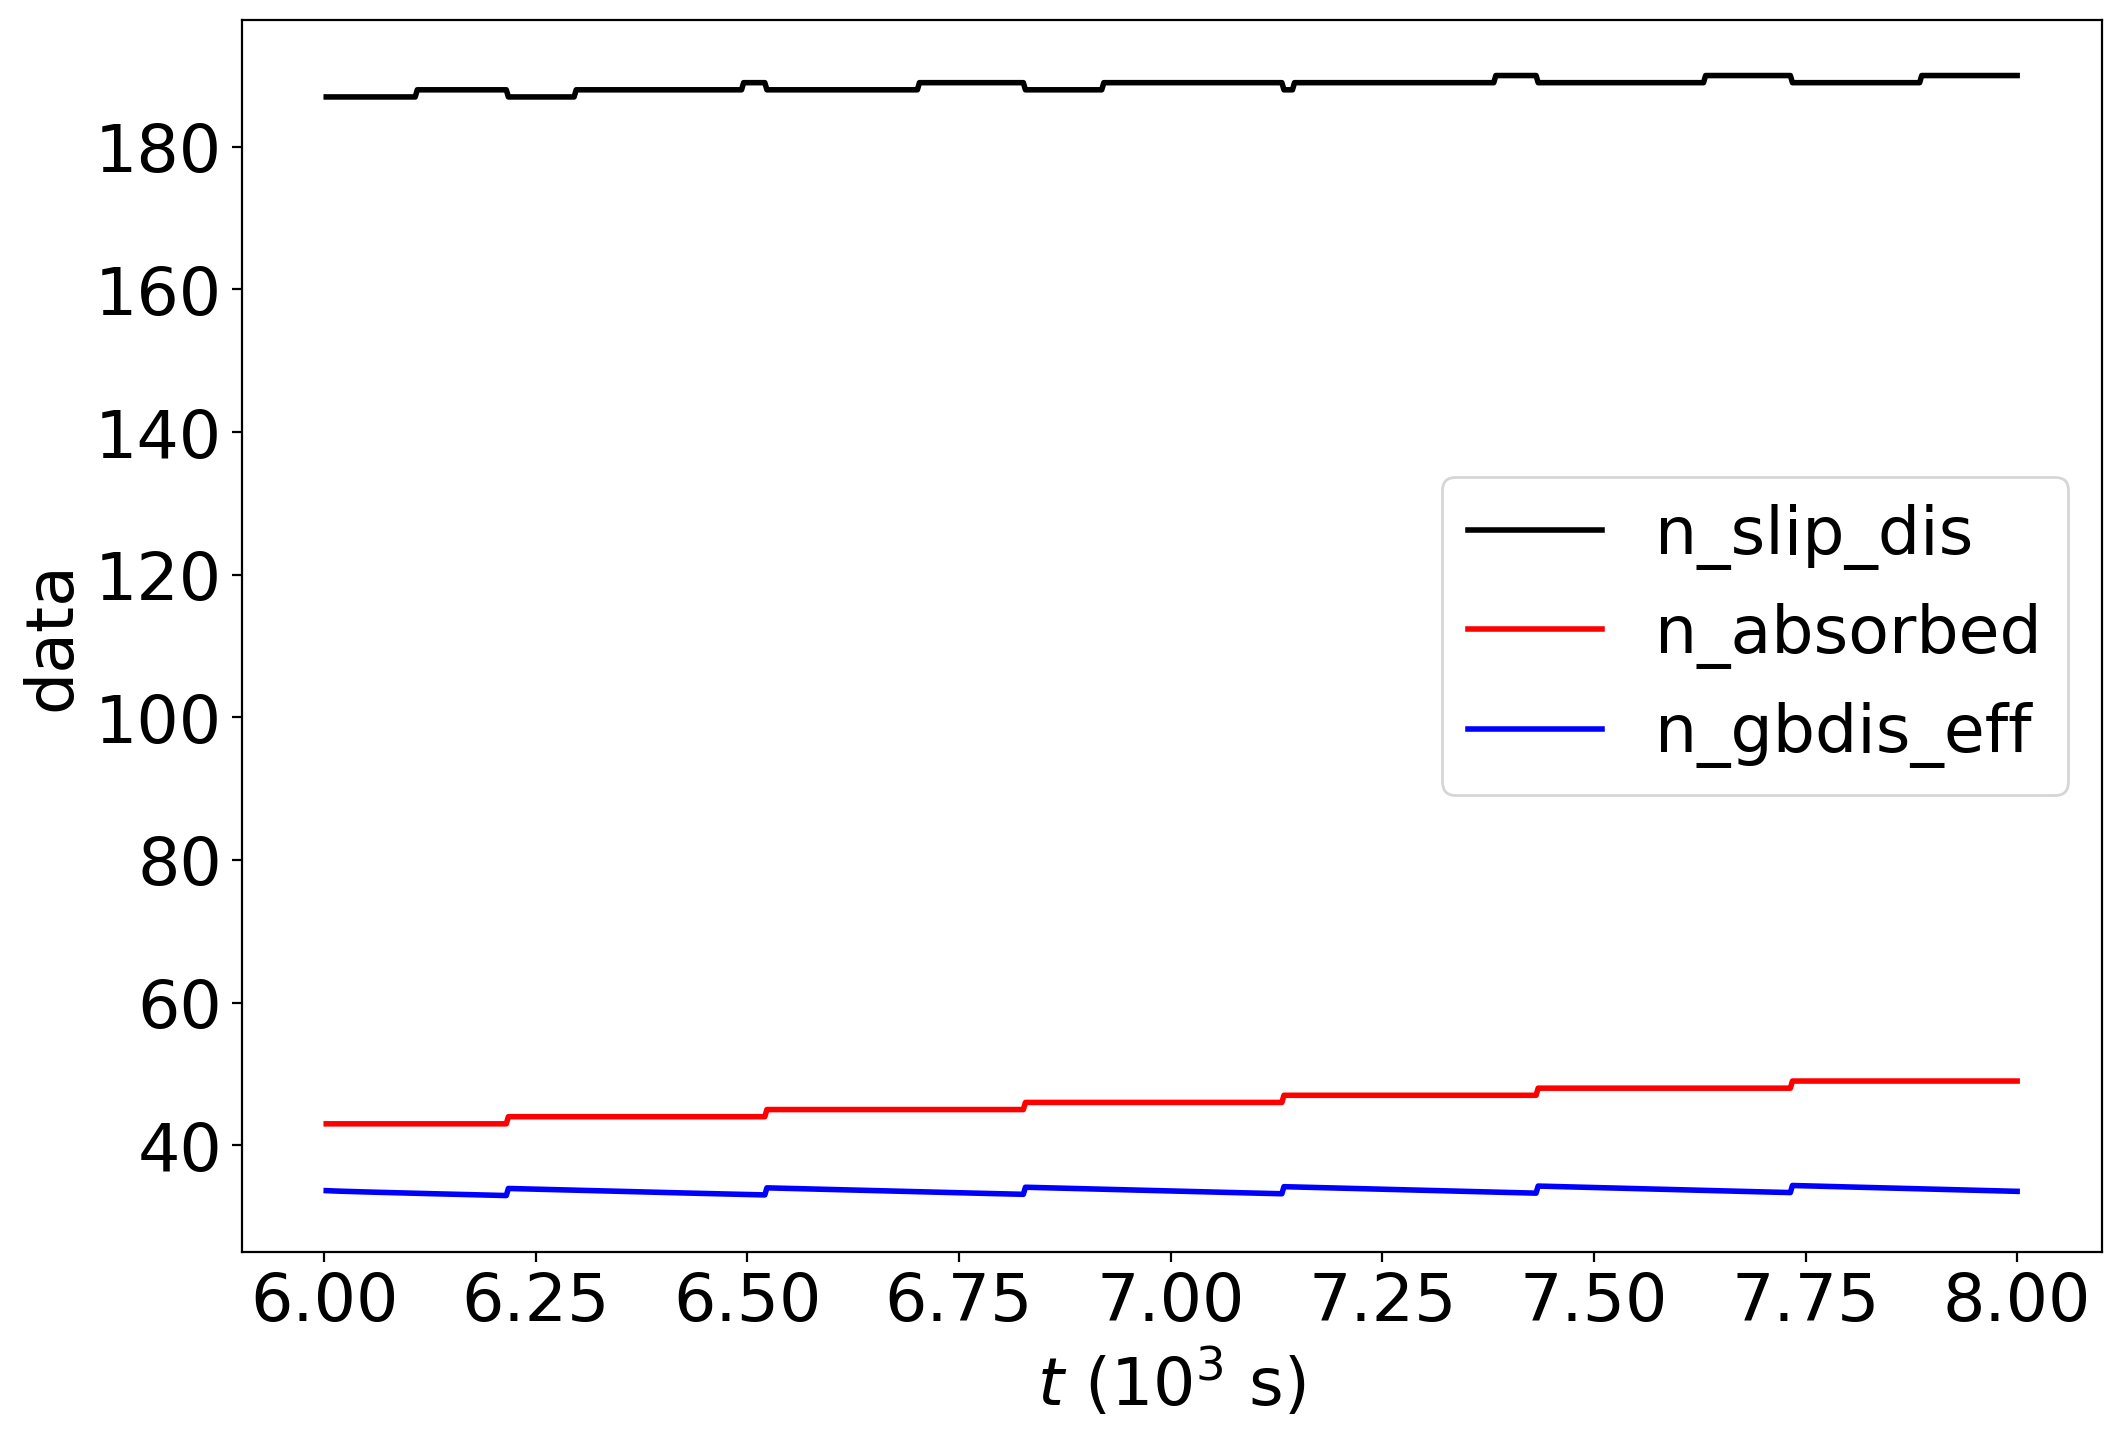

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 9.080690440436836e-12, Nslip: 189.46, Ngb_eff: 33.9085093438167
Data file with H=10.0, L=0.1, T=900.0, tau0=125.0, n=24


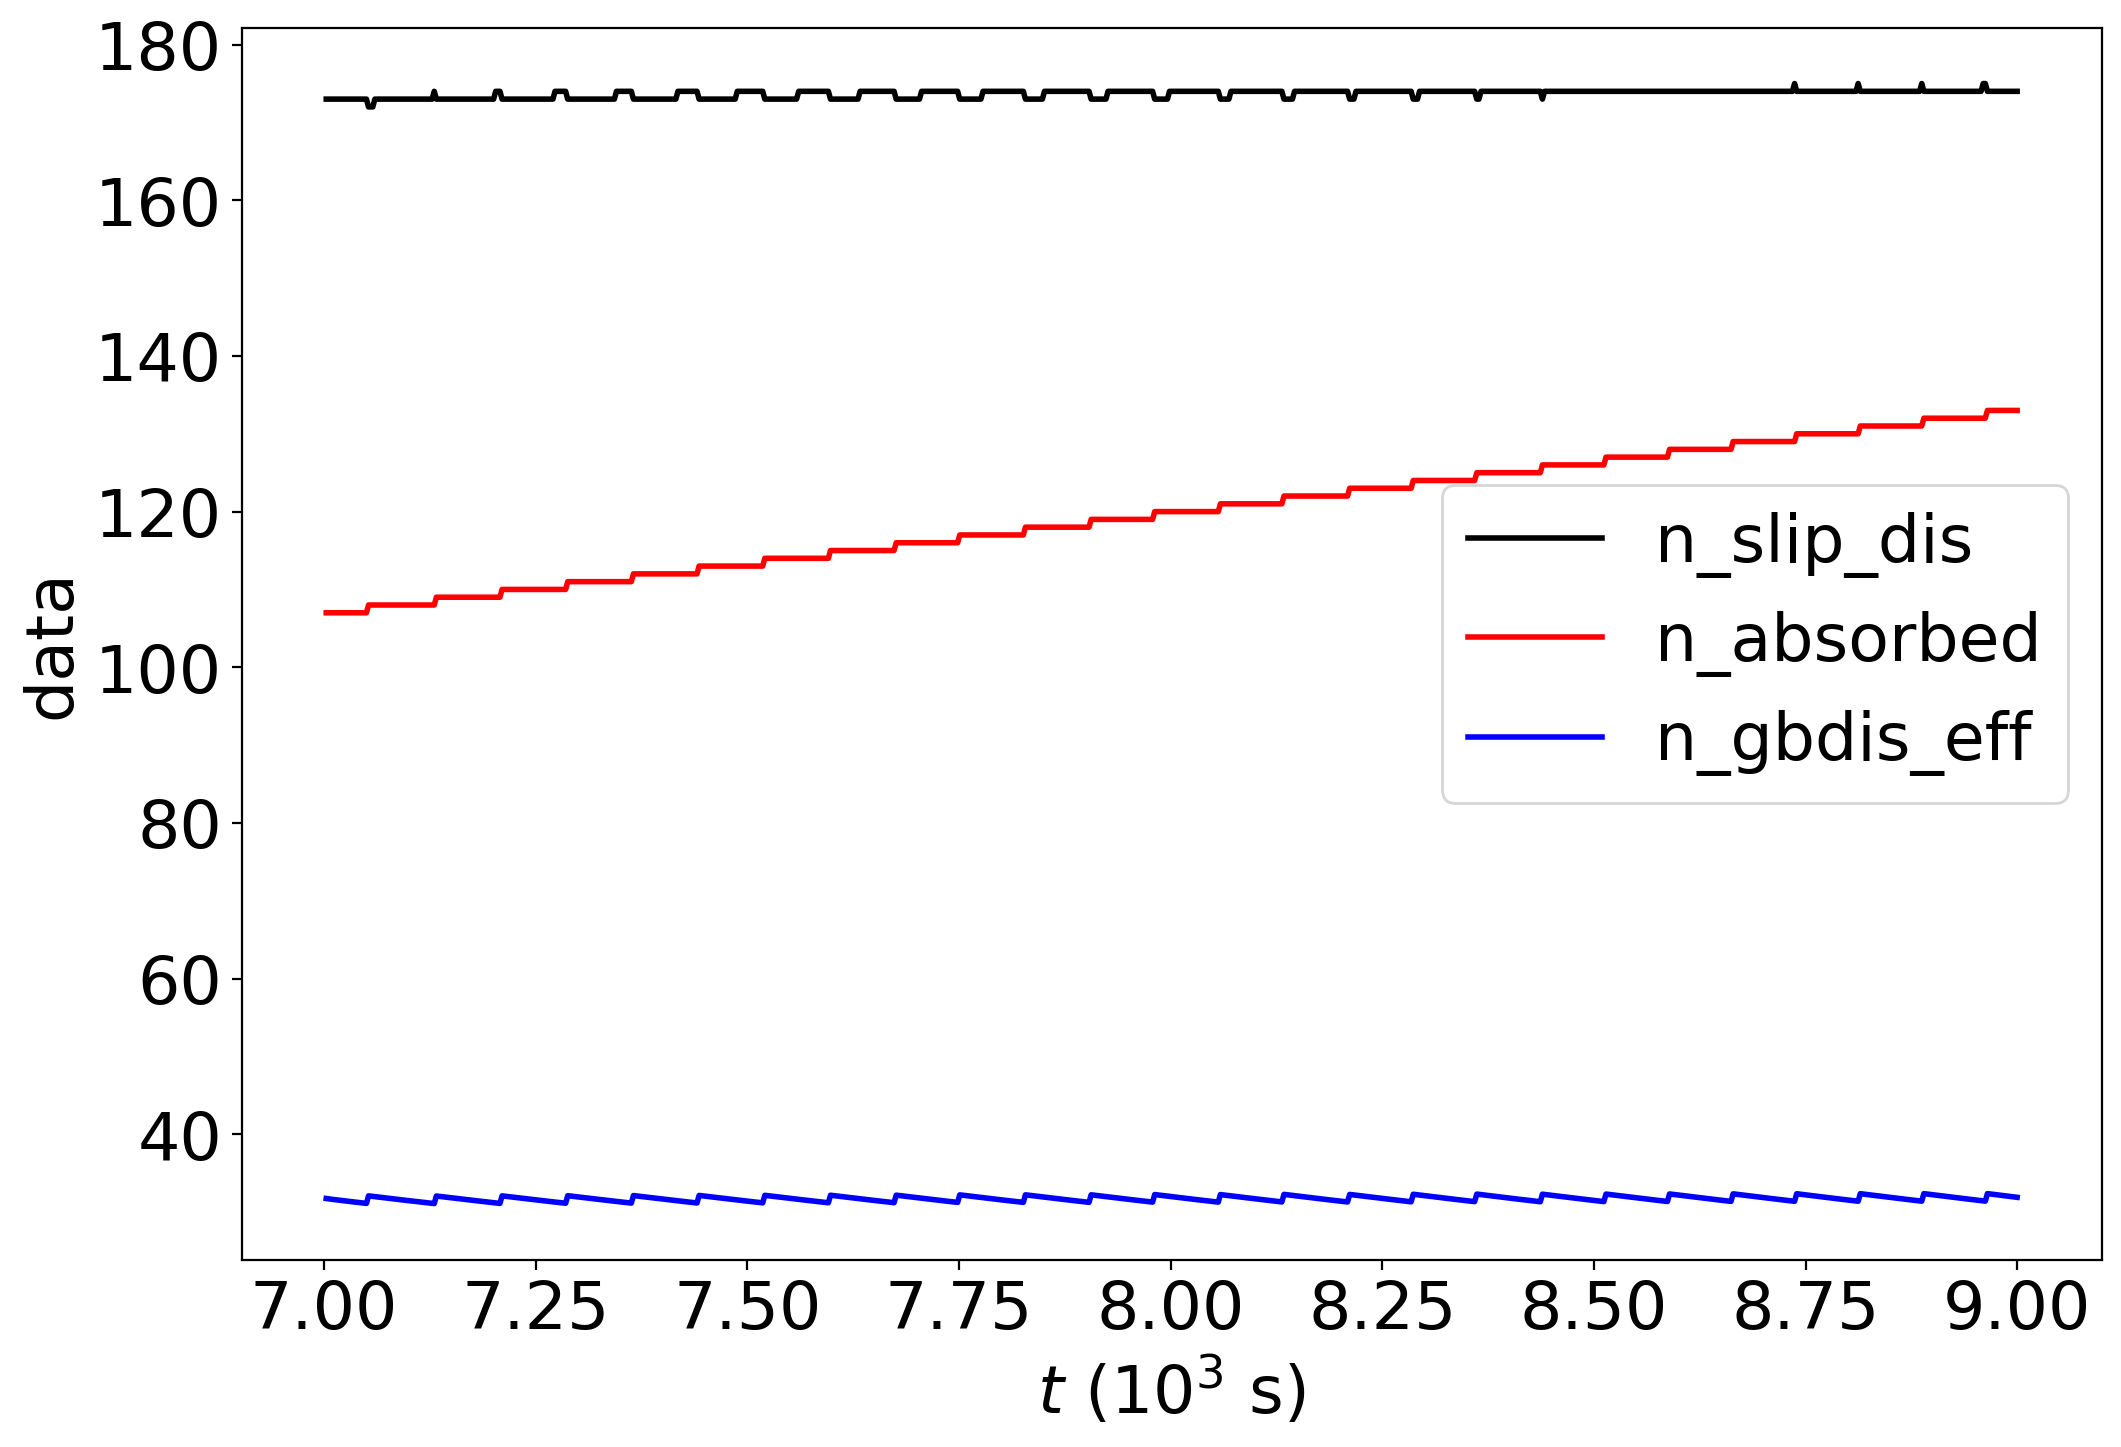

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.344184021077862e-11, Nslip: 174.04, Ngb_eff: 31.893161517994937
Data file with H=10.0, L=0.1, T=800.0, tau0=150.0, n=24


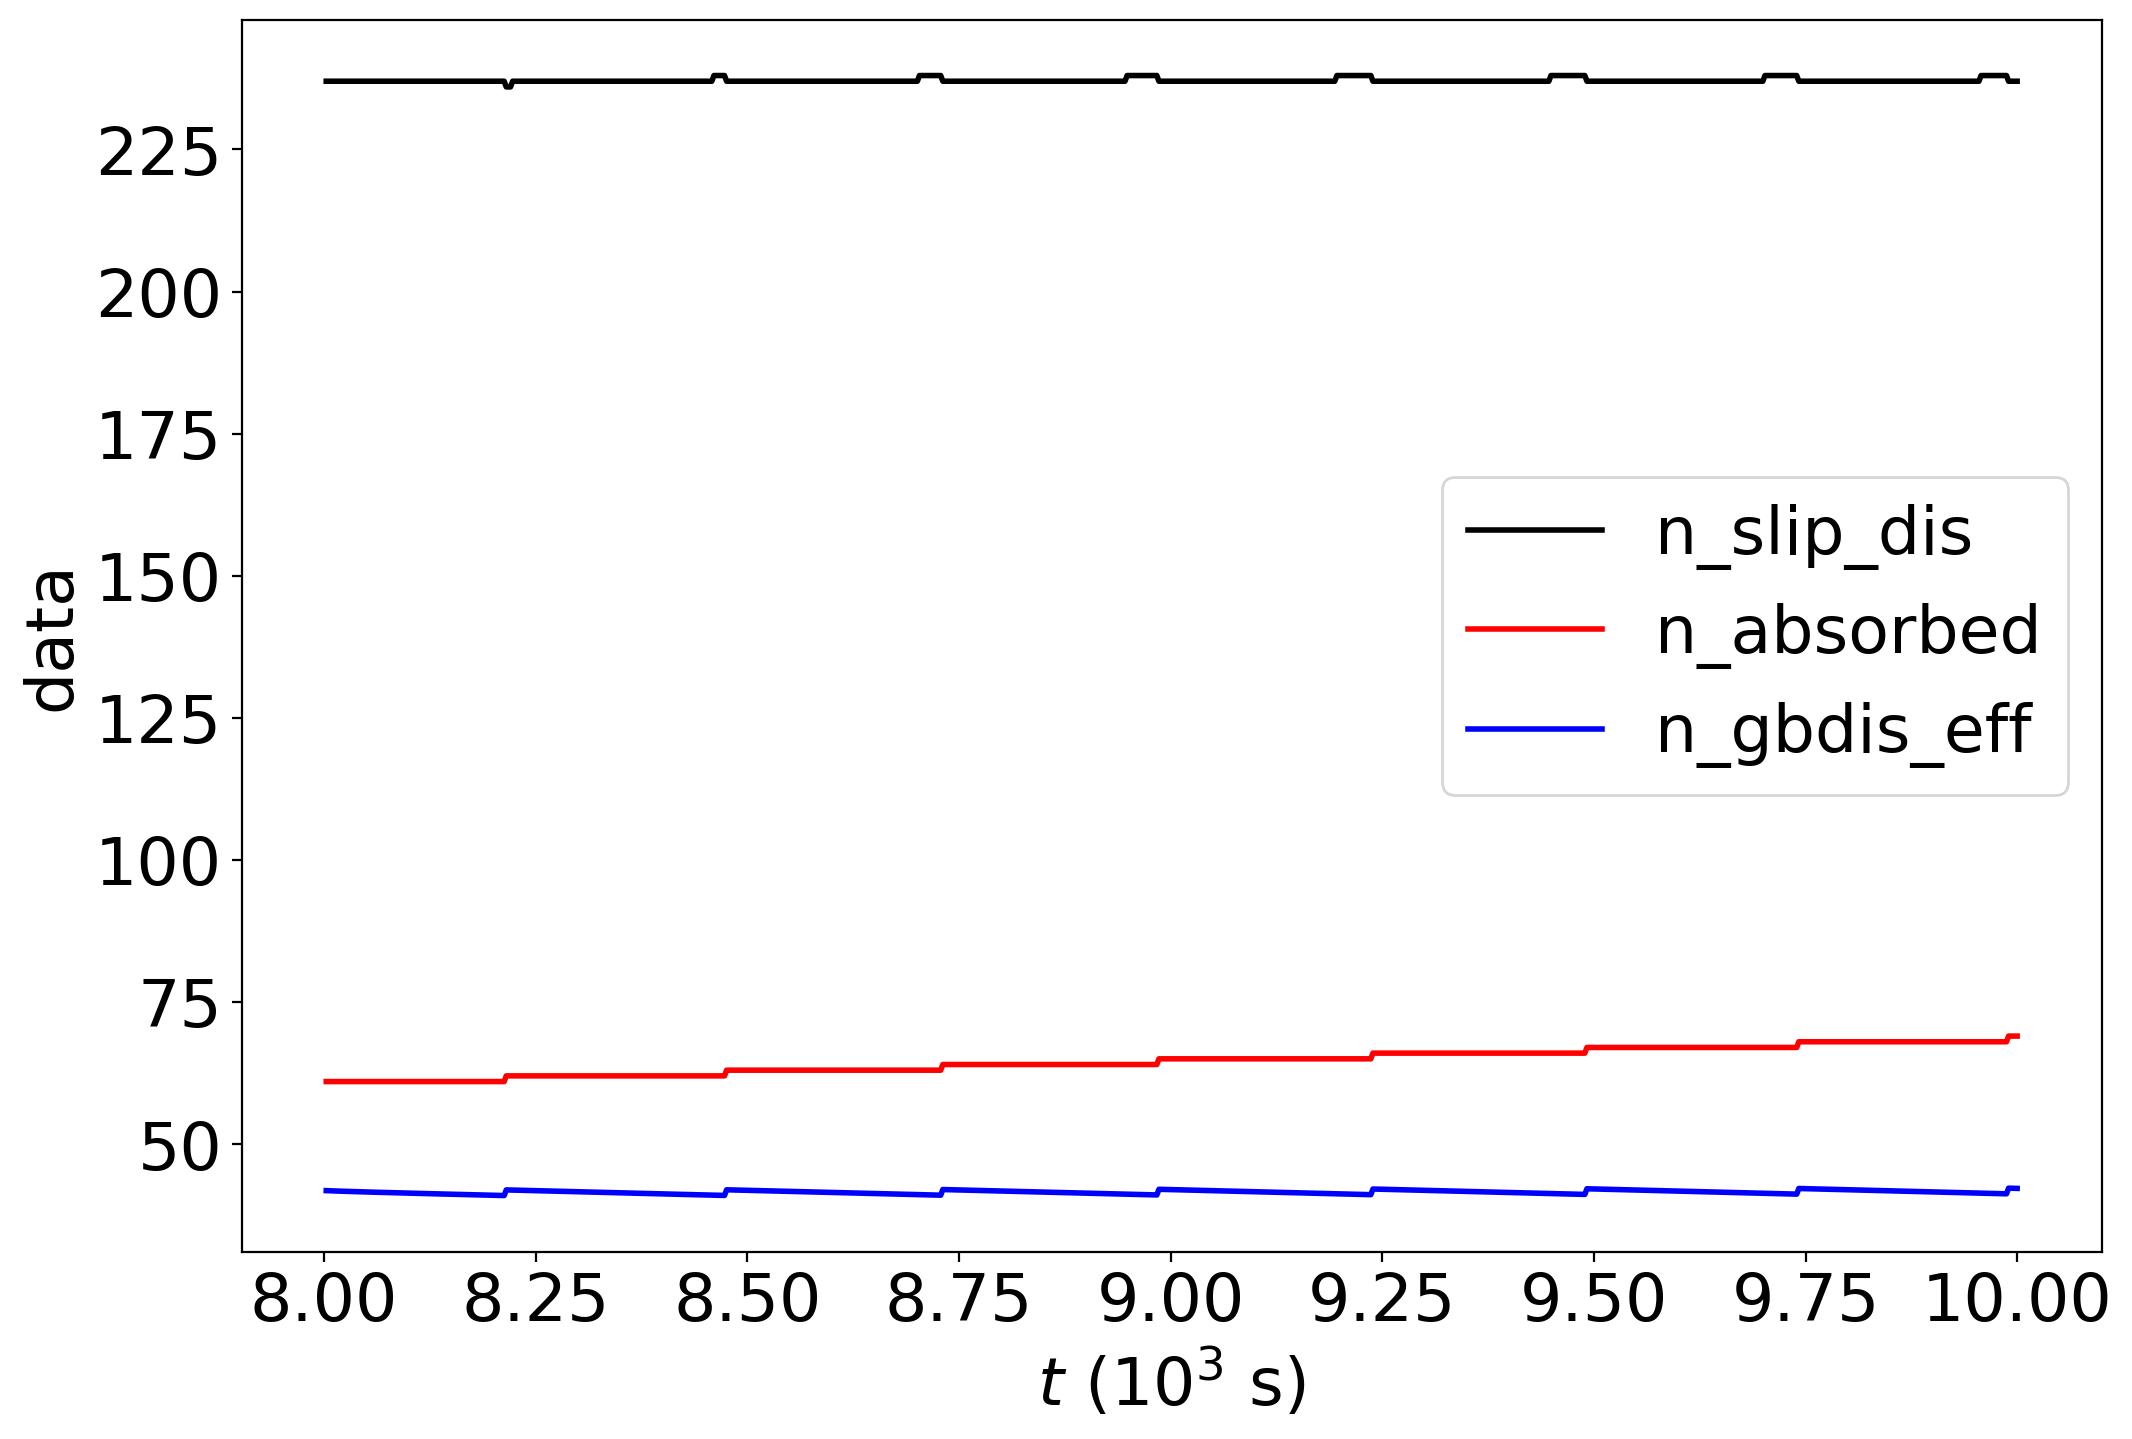

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 9.708210530487831e-12, Nslip: 237.13, Ngb_eff: 41.719687383041794
Data file with H=10.0, L=0.1, T=900.0, tau0=150.0, n=24


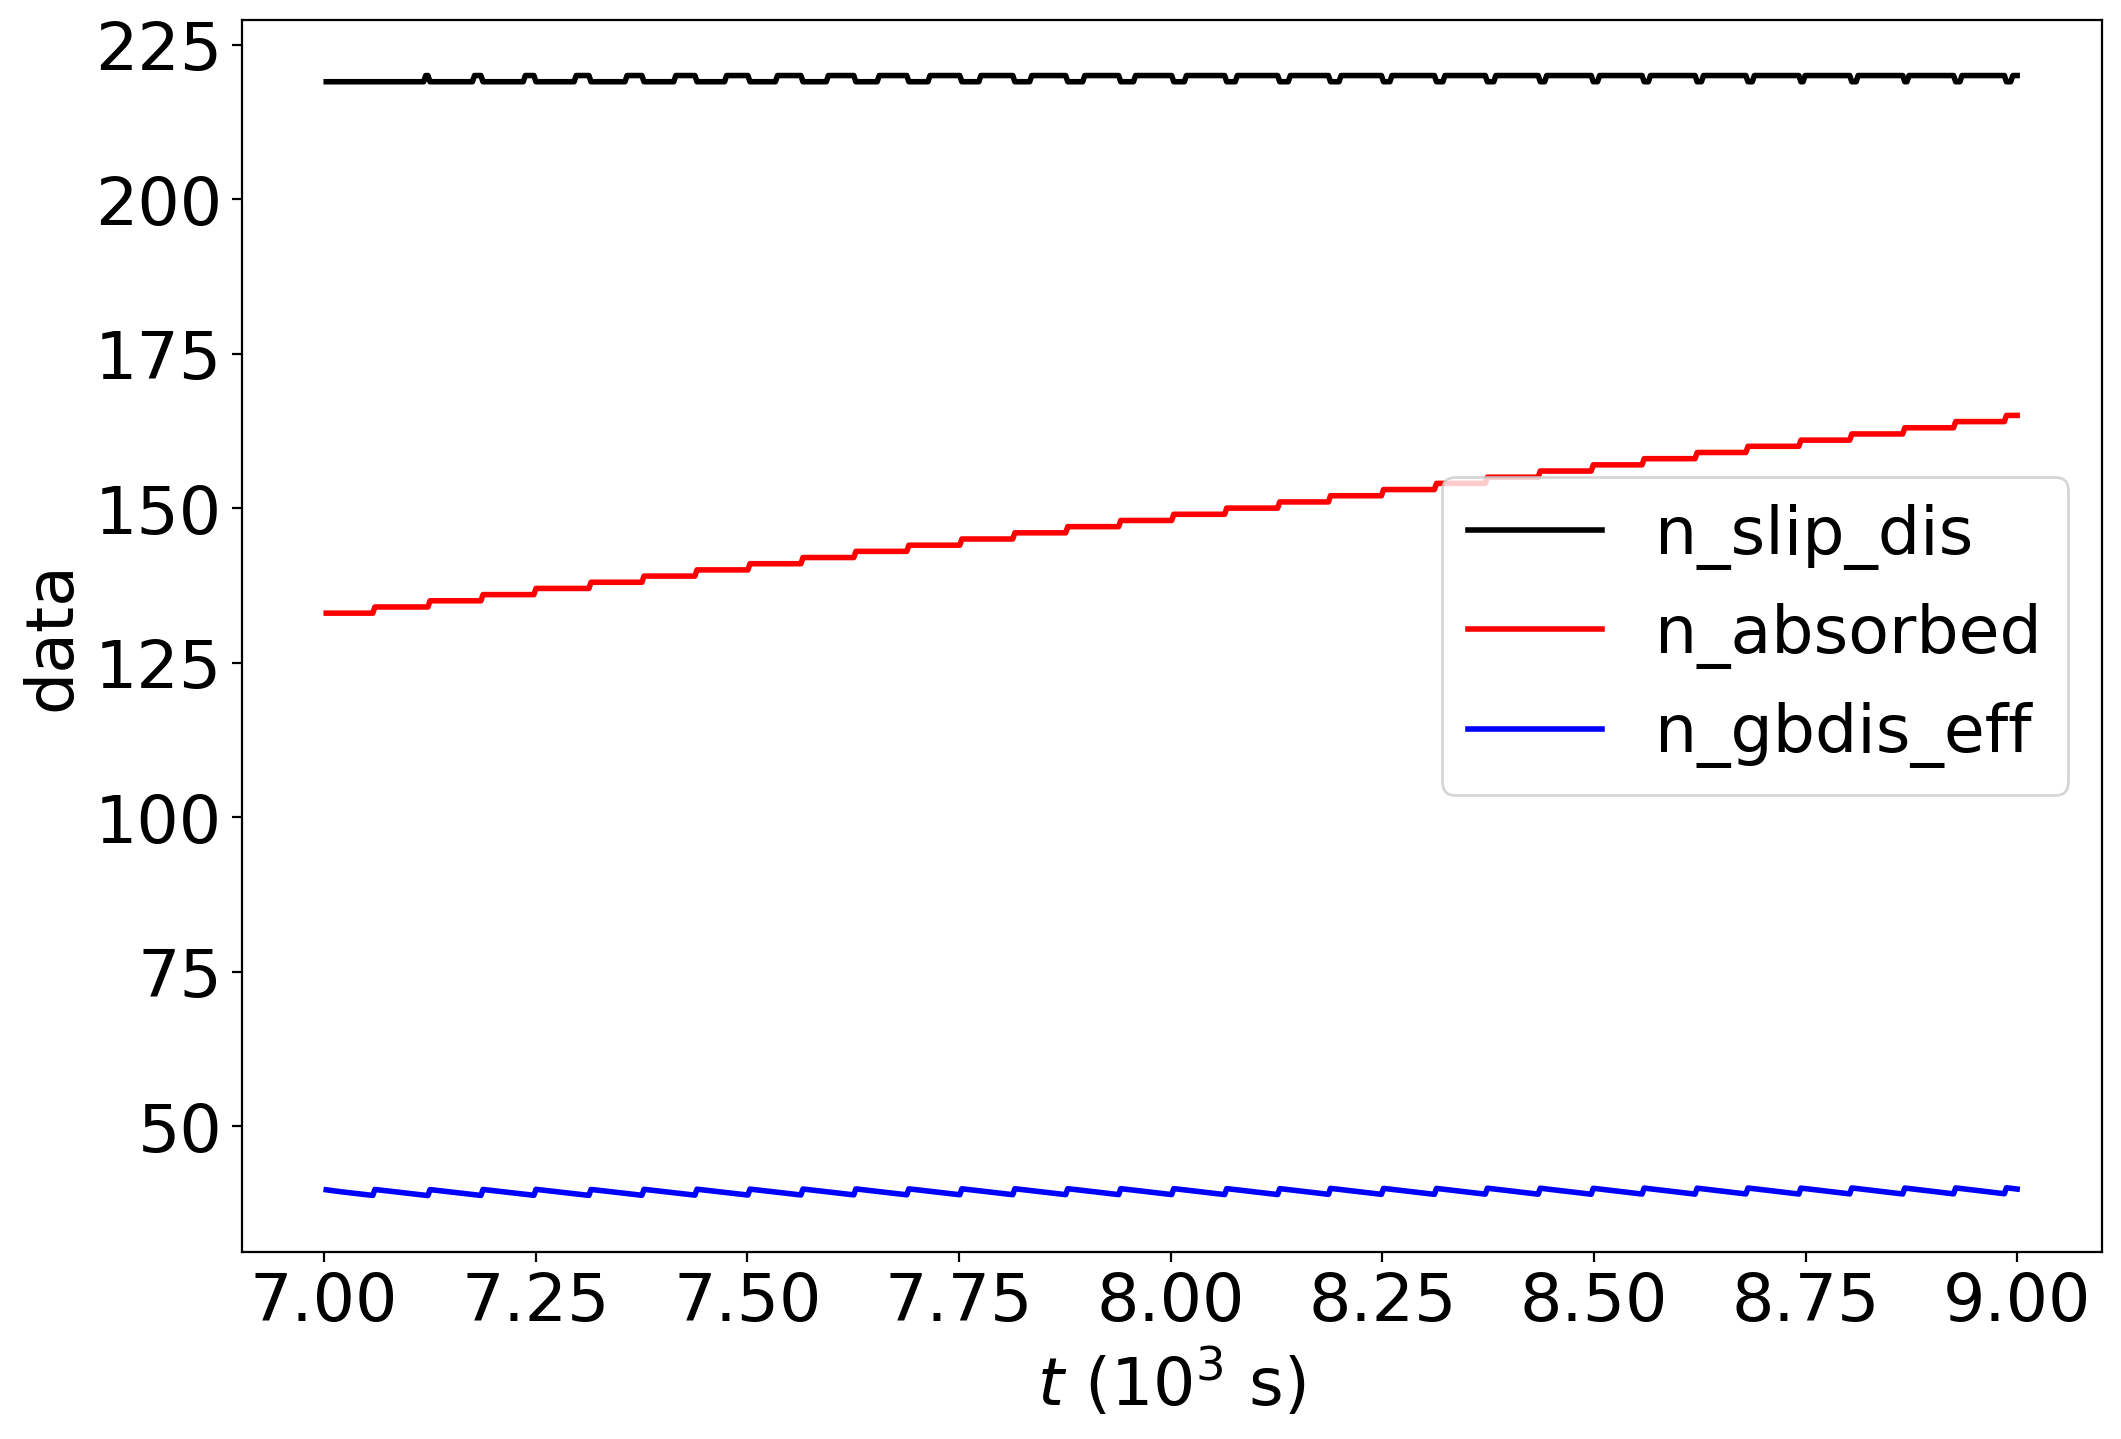

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.0819102728535027e-11, Nslip: 219.89, Ngb_eff: 39.50805208158527
Data file with H=10.0, L=0.1, T=1000.0, tau0=25.0, n=24


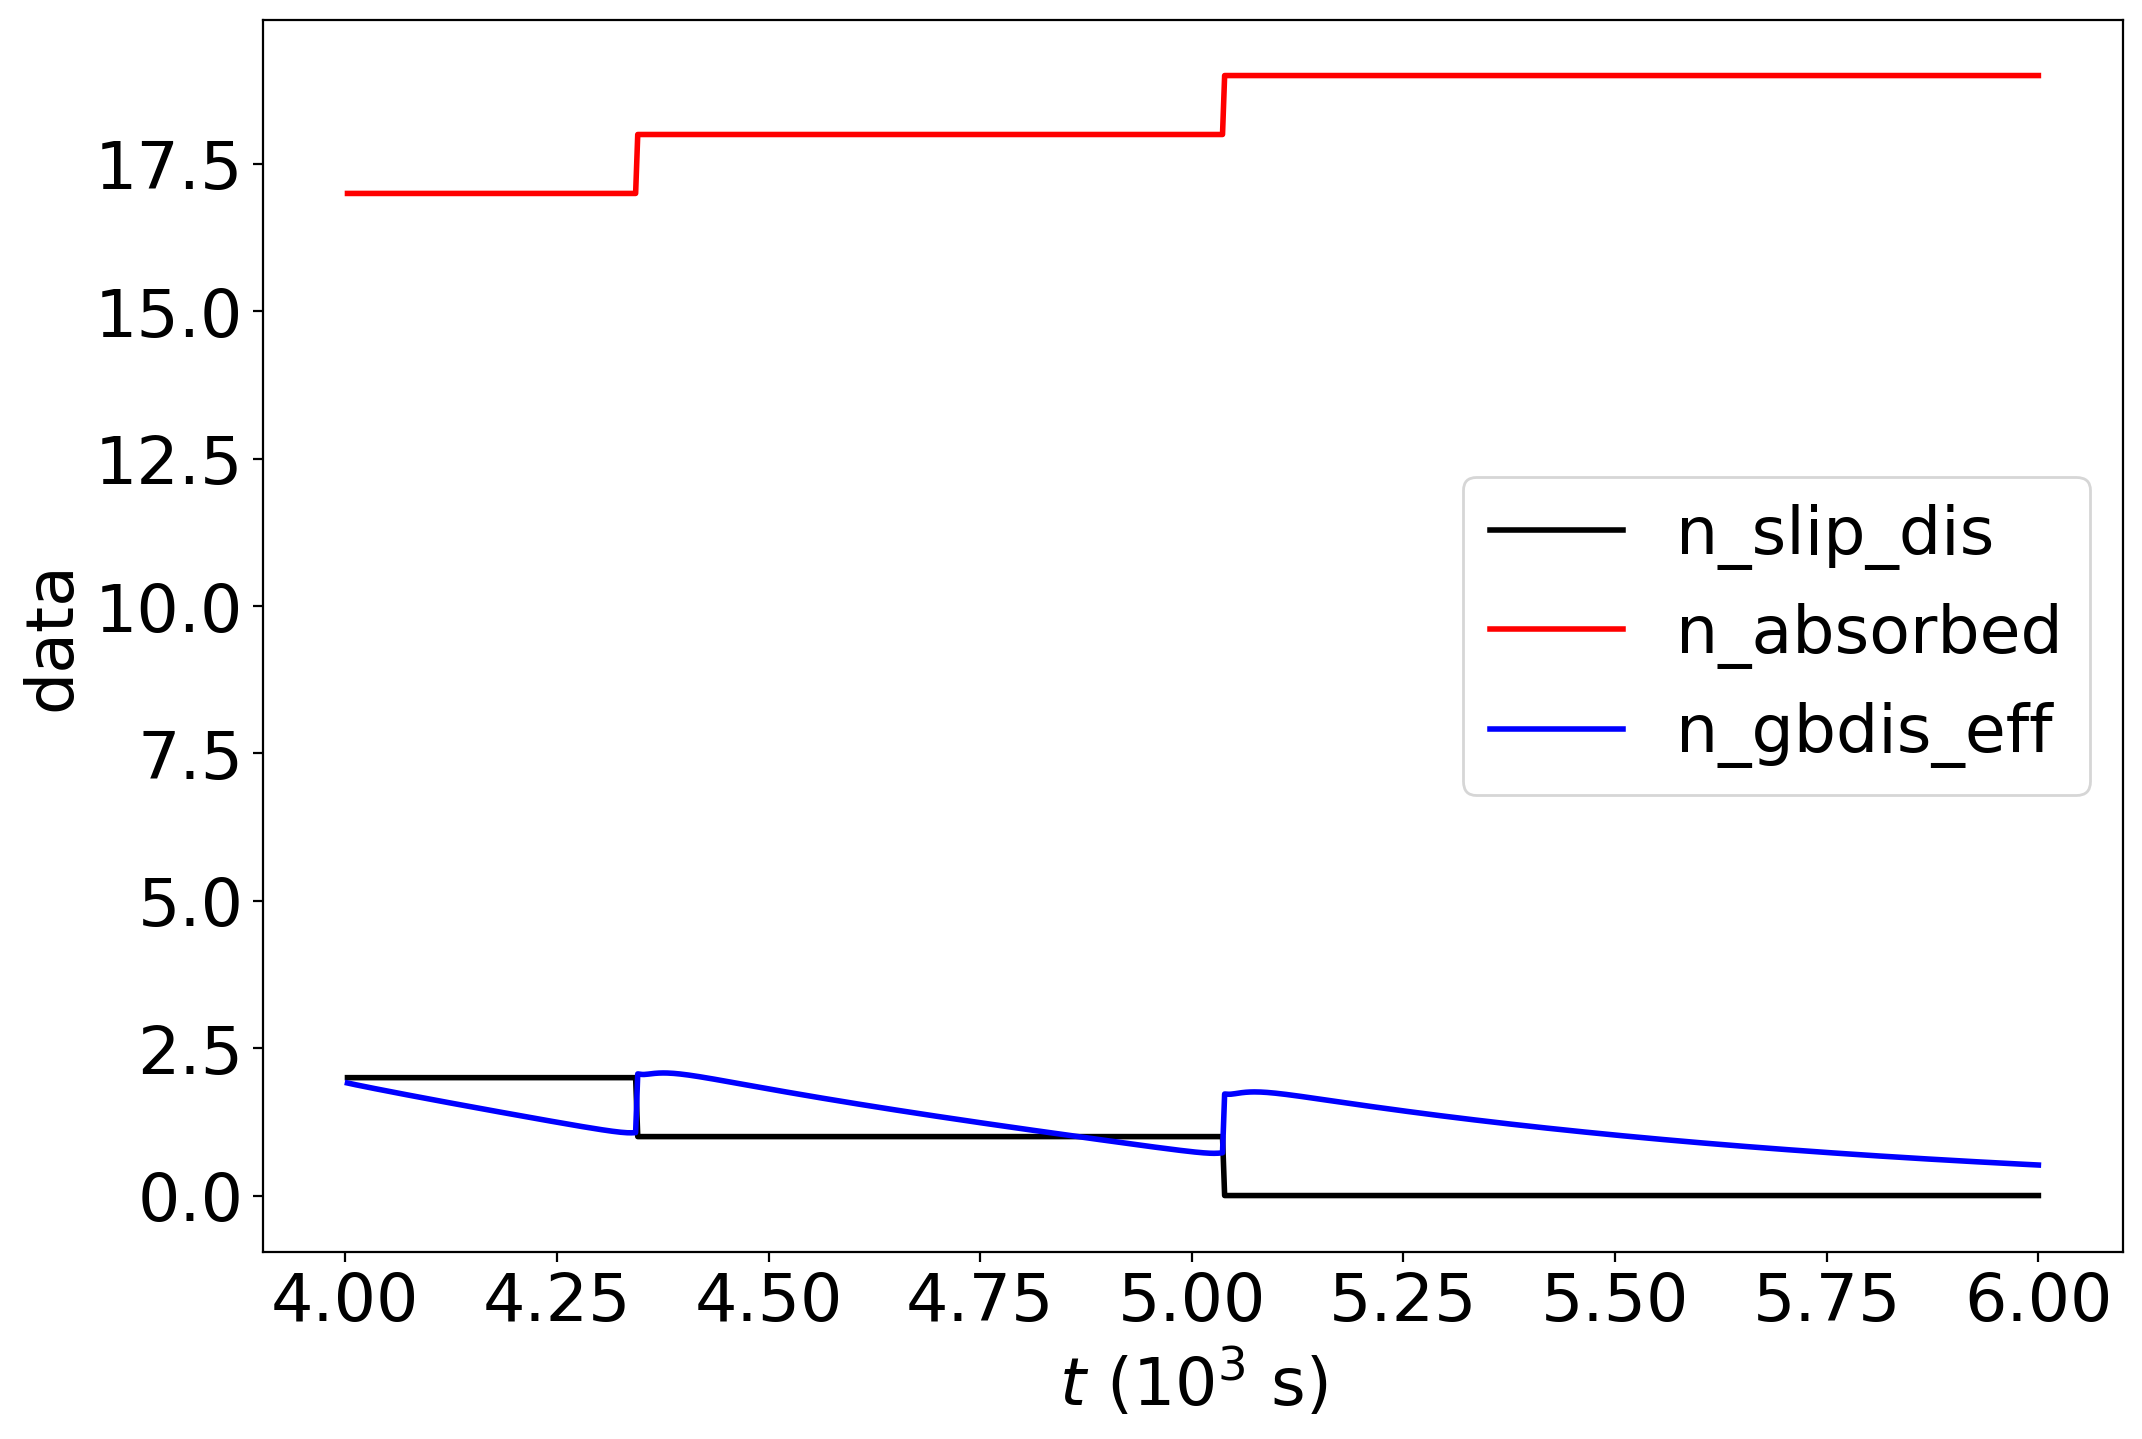

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 0.0, Nslip: 0.0, Ngb_eff: 0.6173393961422066
Data file with H=10.0, L=0.1, T=800.0, tau0=25.0, n=24


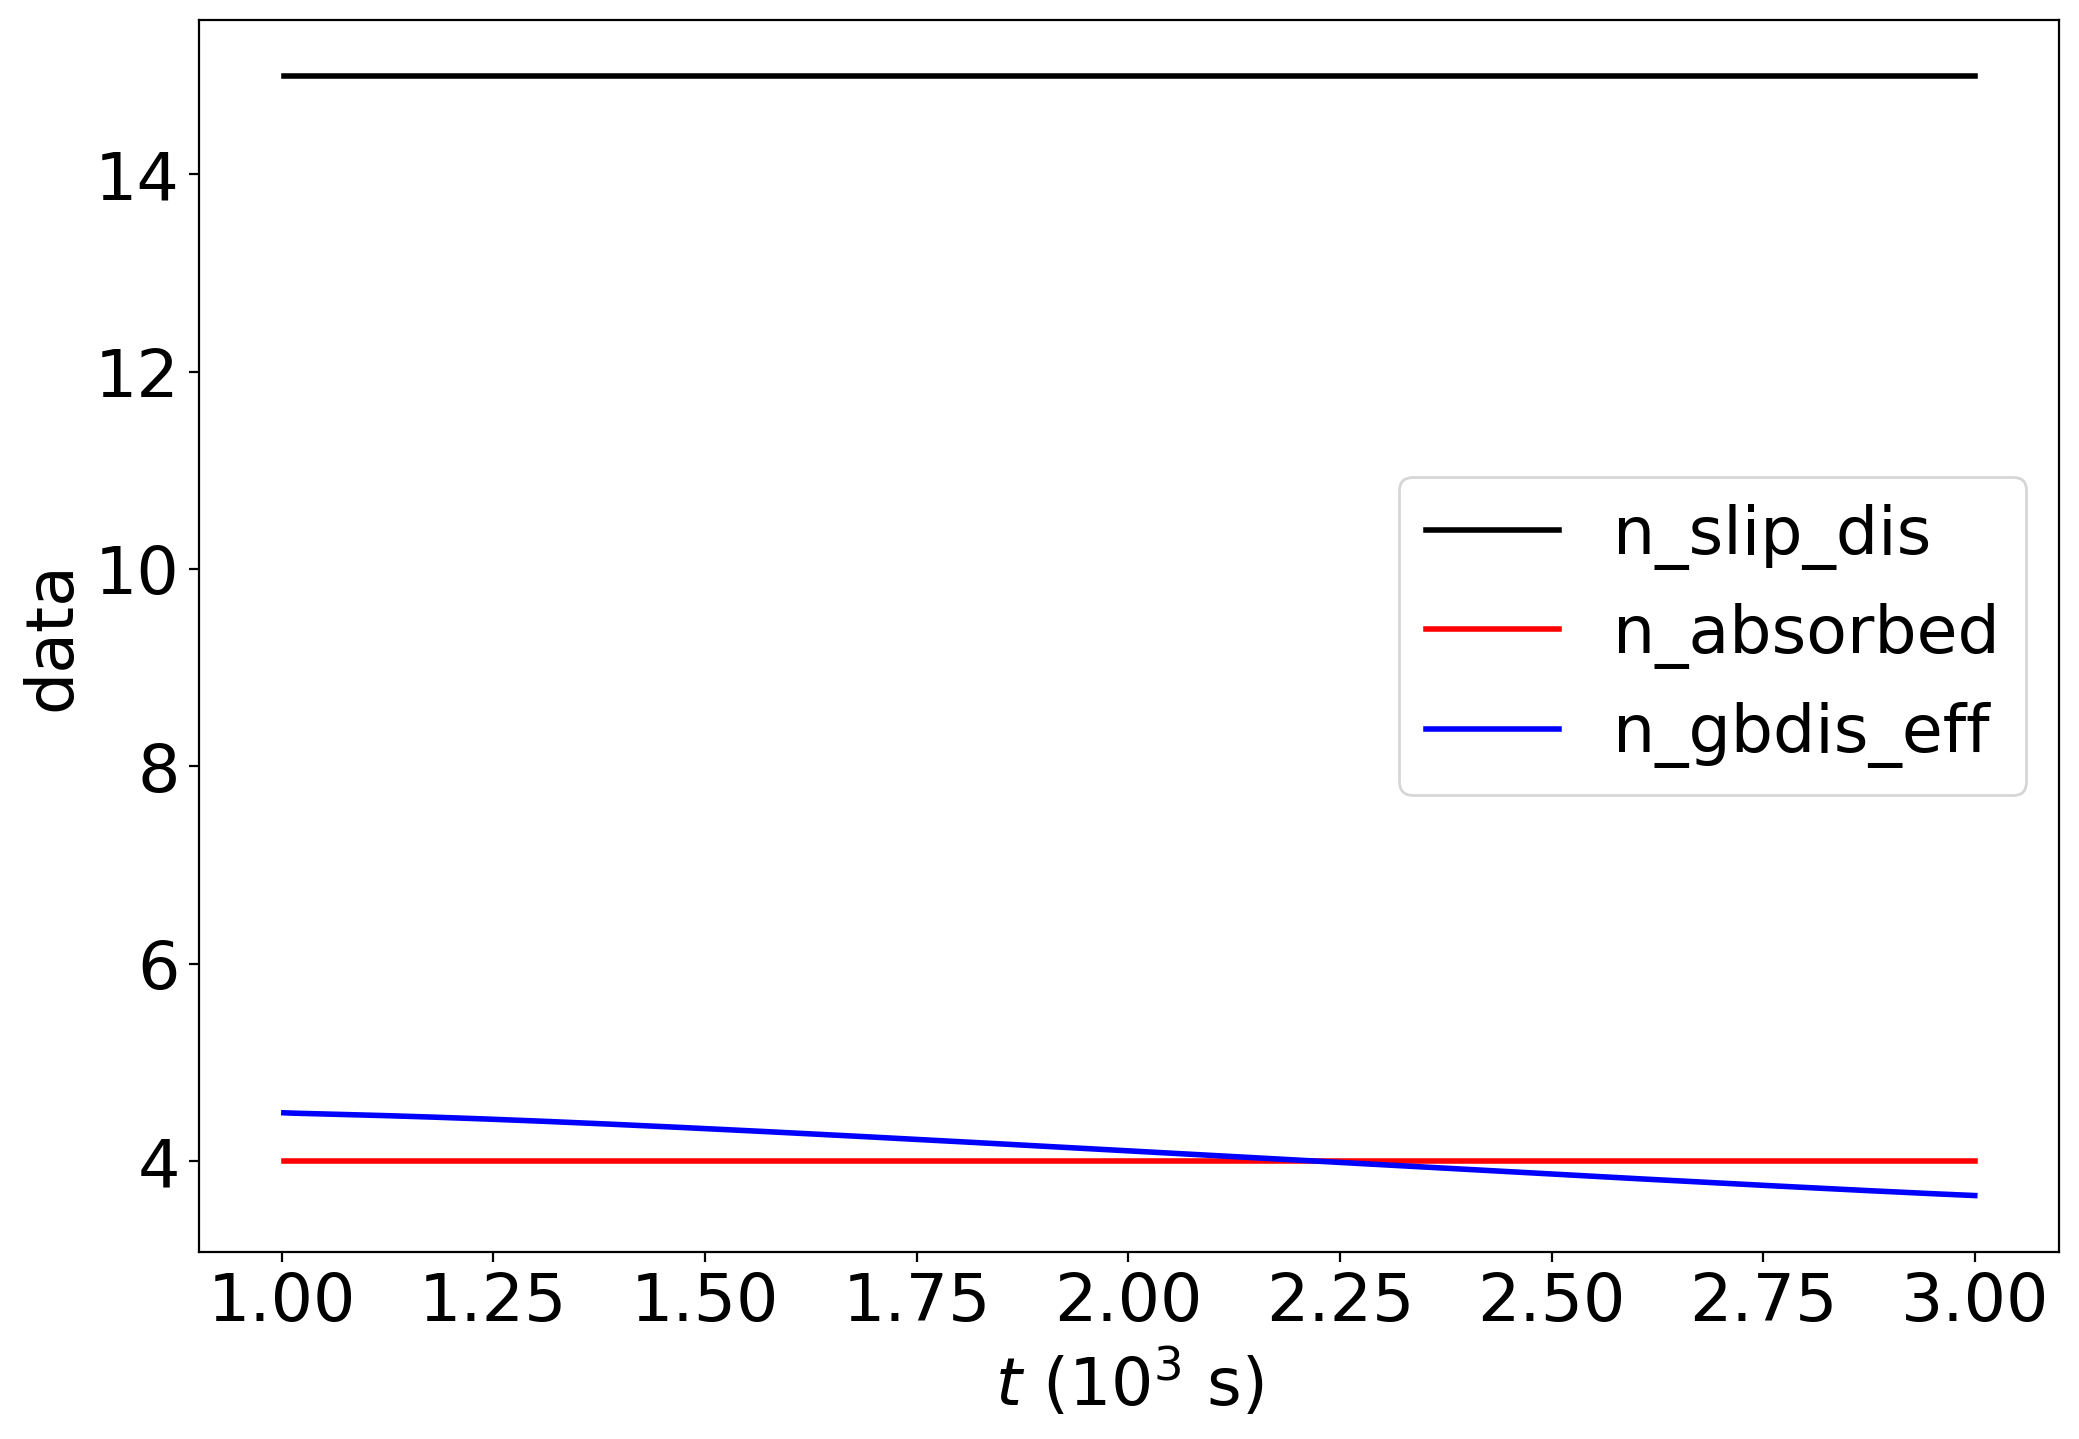

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.8198940483671333e-13, Nslip: 15.0, Ngb_eff: 3.699308171662998
Data file with H=10.0, L=0.1, T=900.0, tau0=25.0, n=24


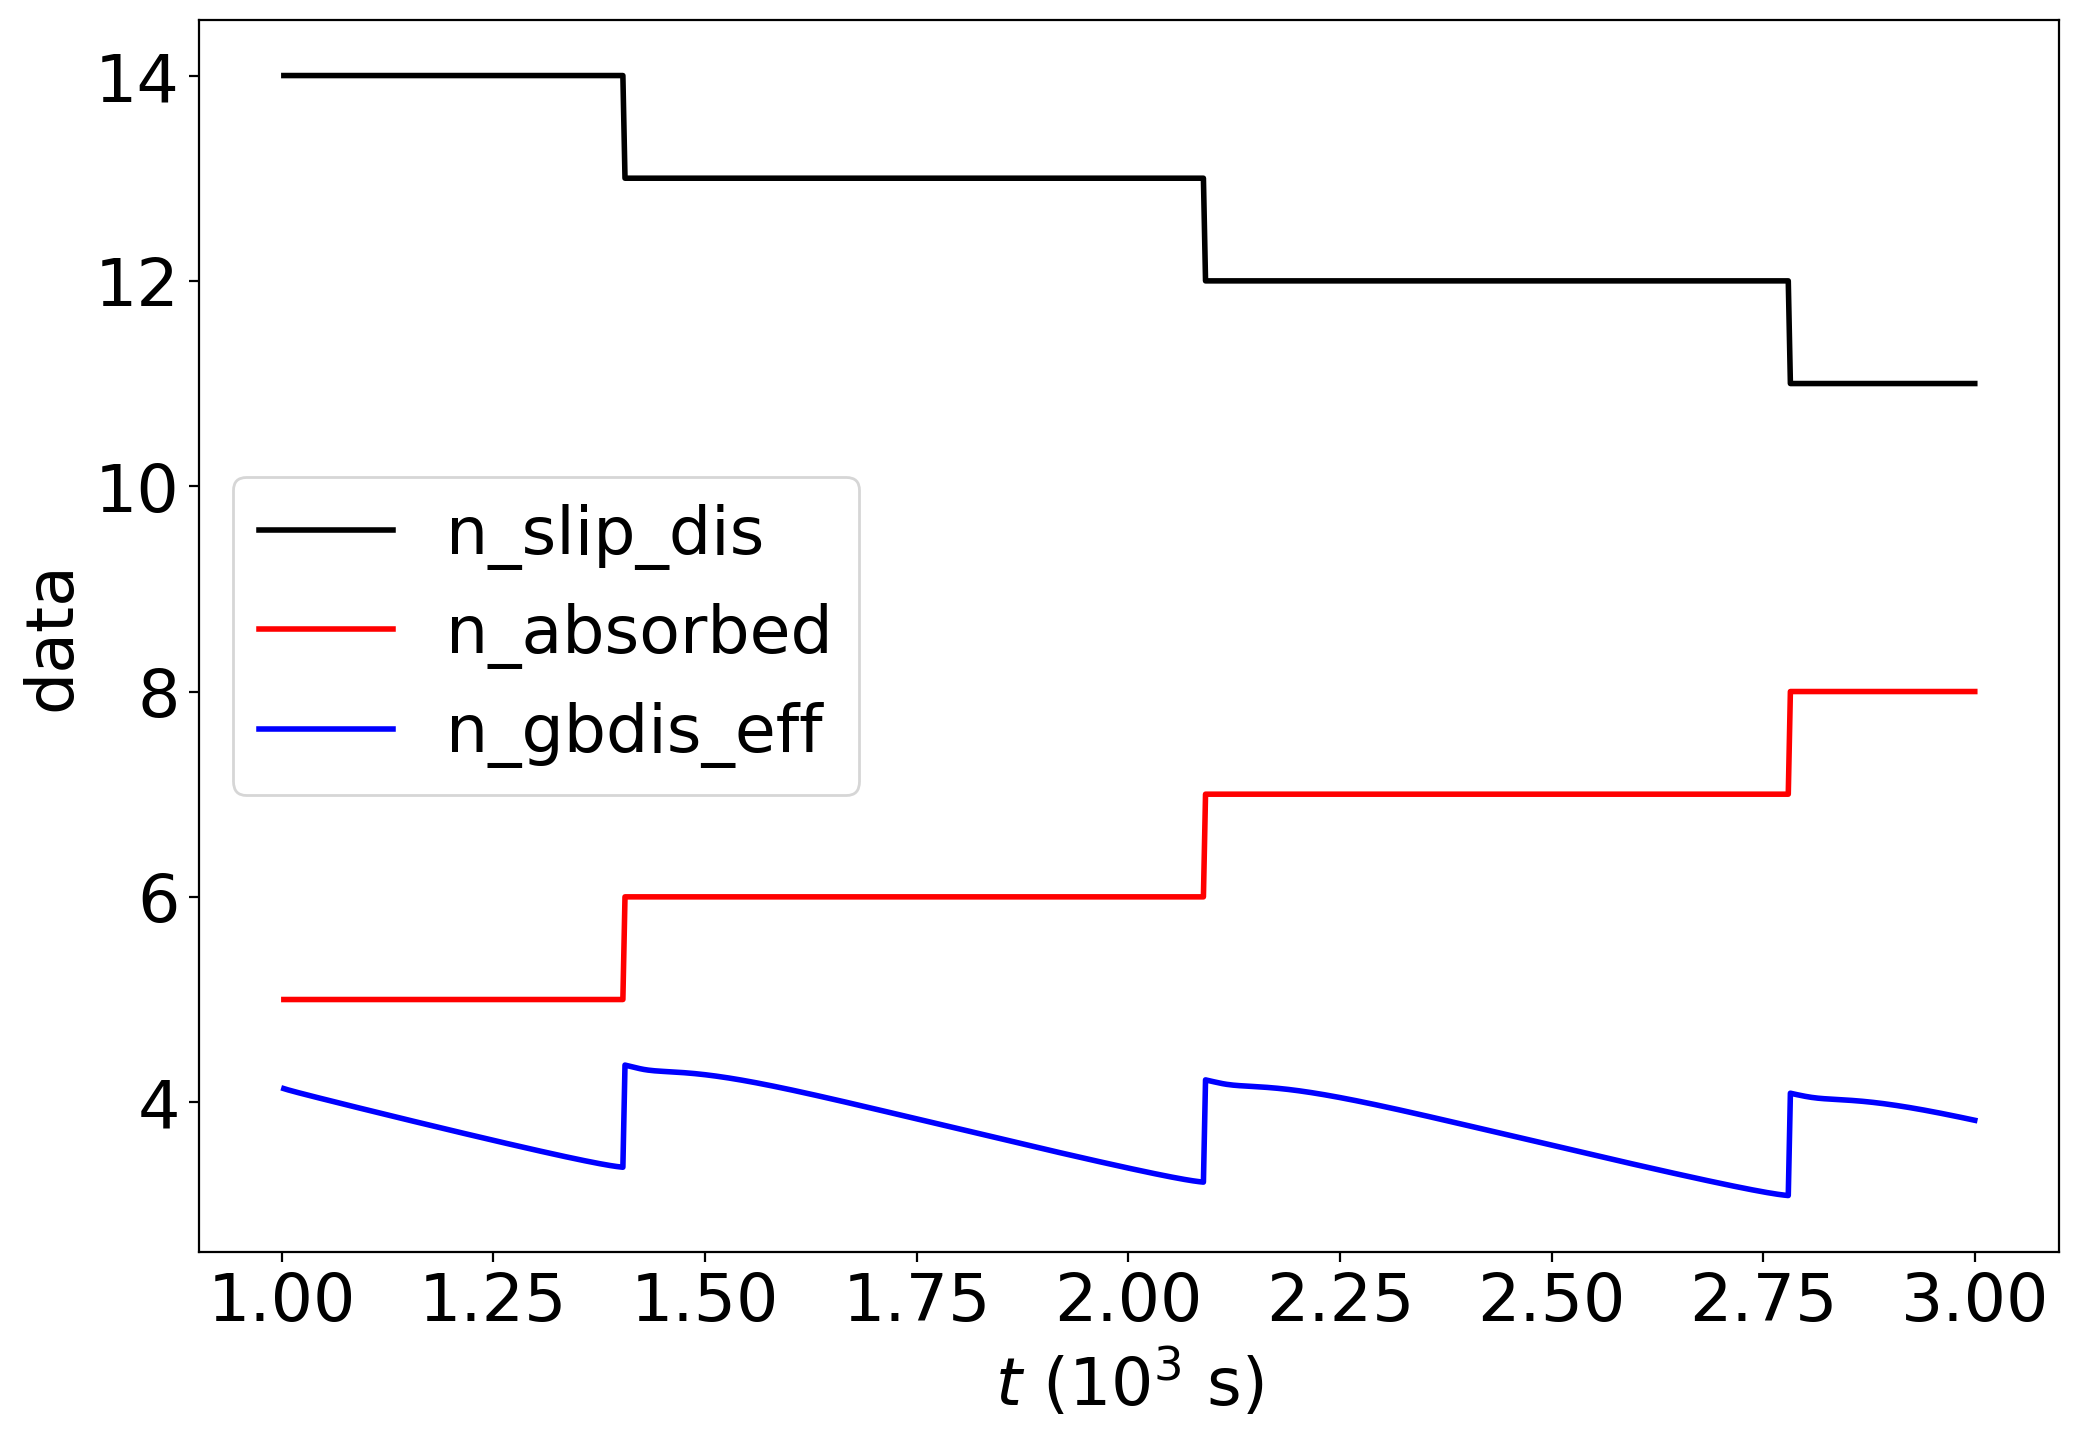

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 6.162234149484972e-13, Nslip: 11.12, Ngb_eff: 3.866500286042152
Data file with H=10.0, L=0.1, T=1000.0, tau0=50.0, n=24


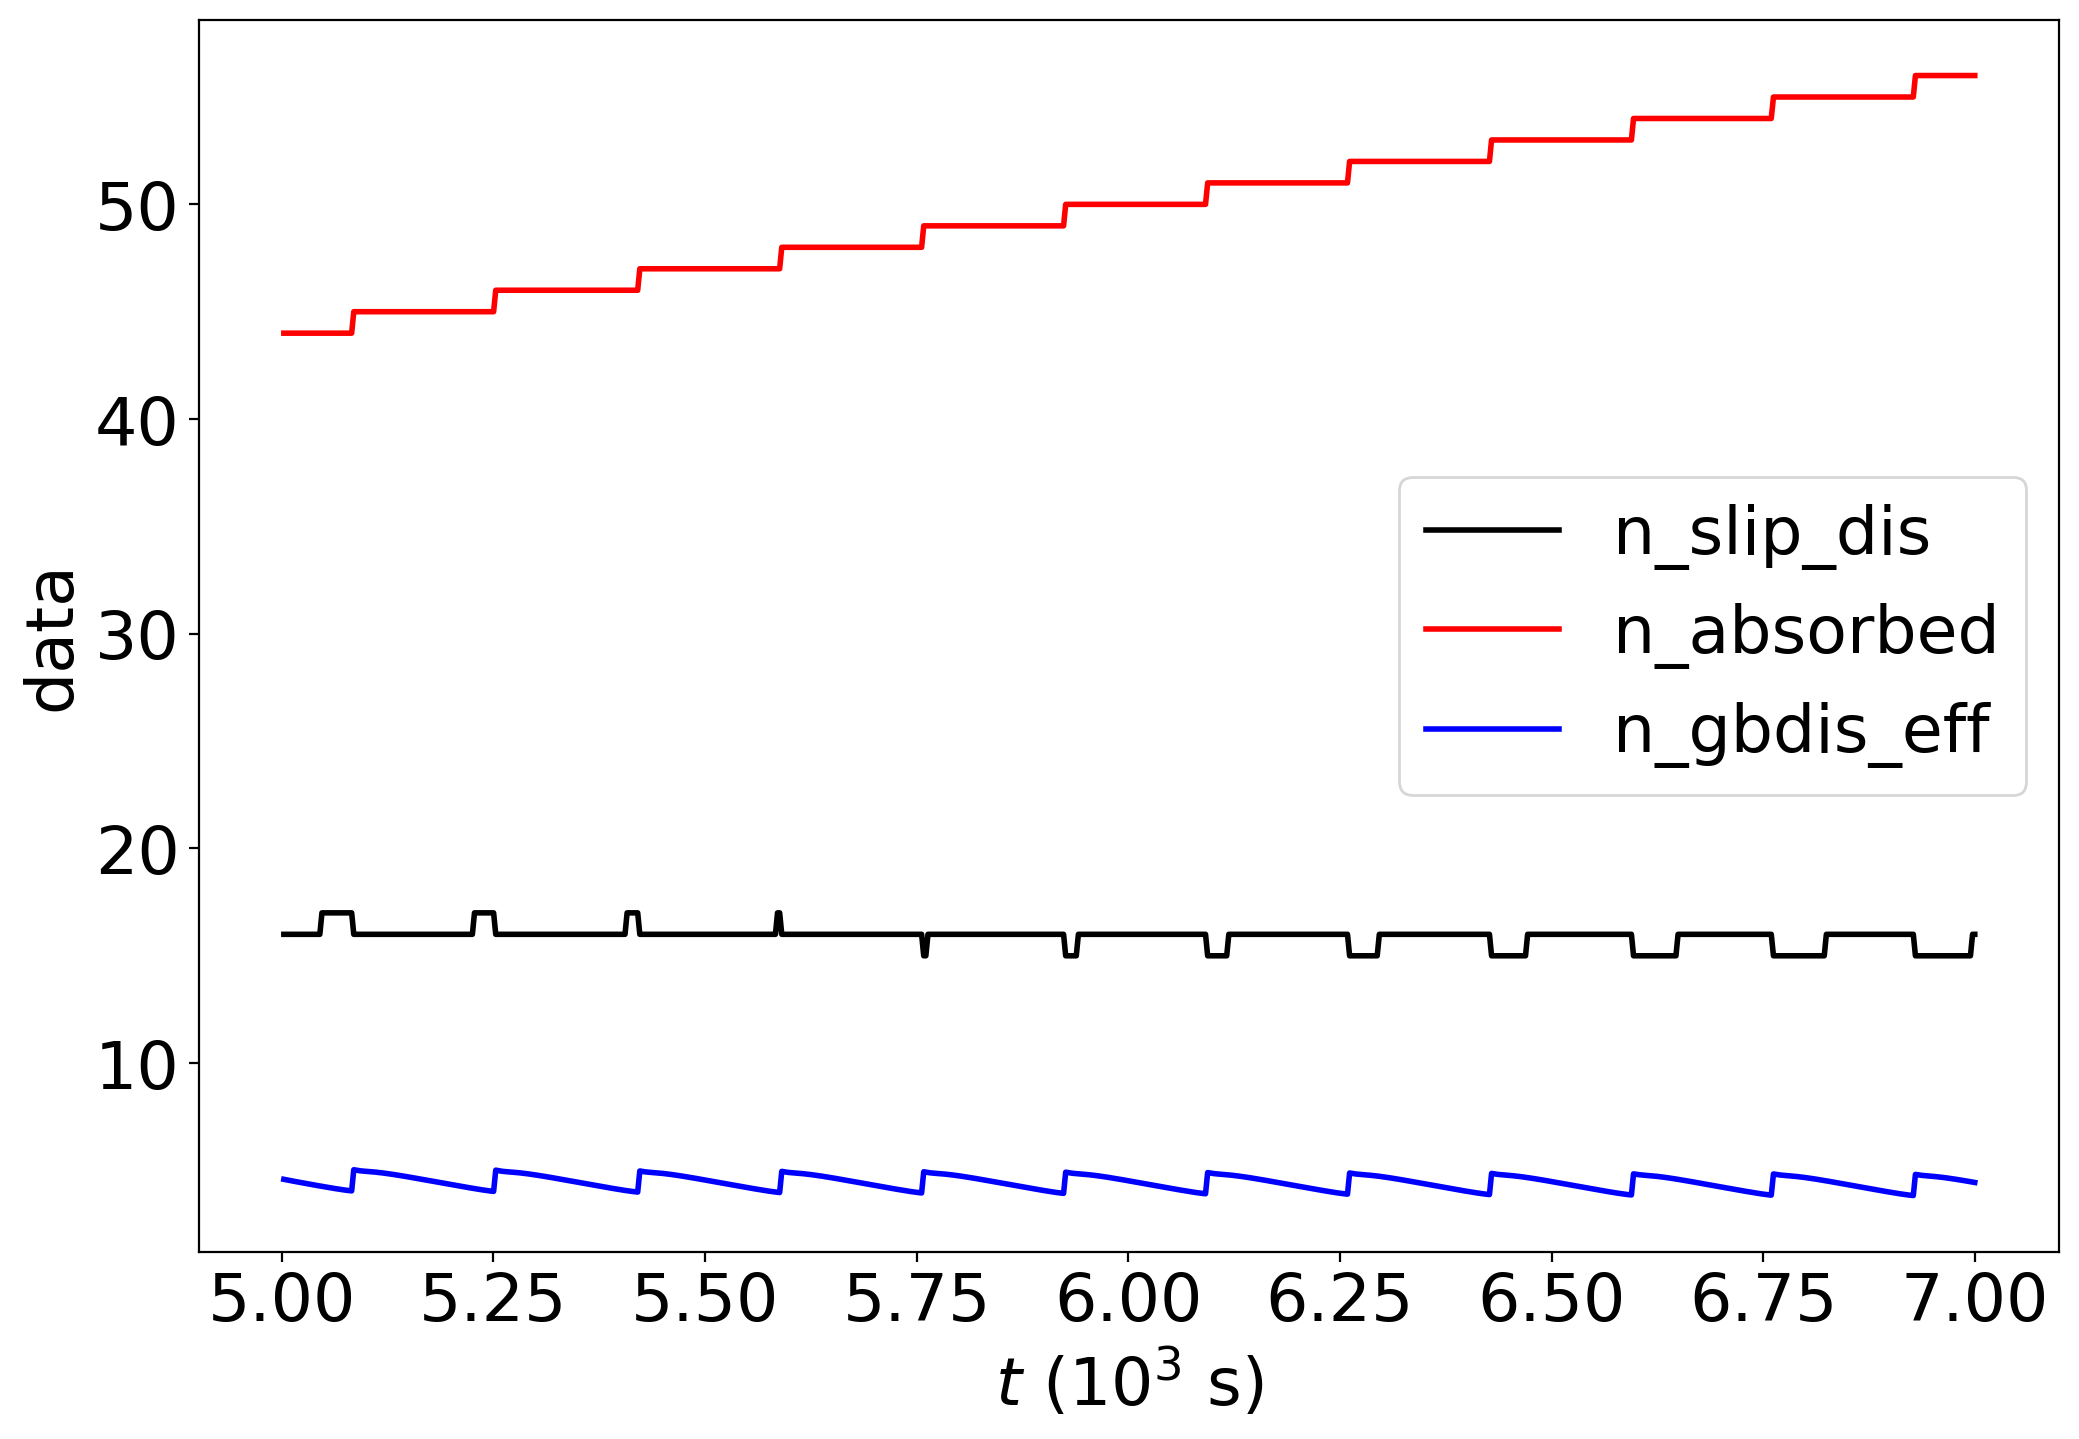

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.4055438742743837e-11, Nslip: 15.48, Ngb_eff: 4.423126464907423
Data file with H=10.0, L=0.1, T=800.0, tau0=50.0, n=24


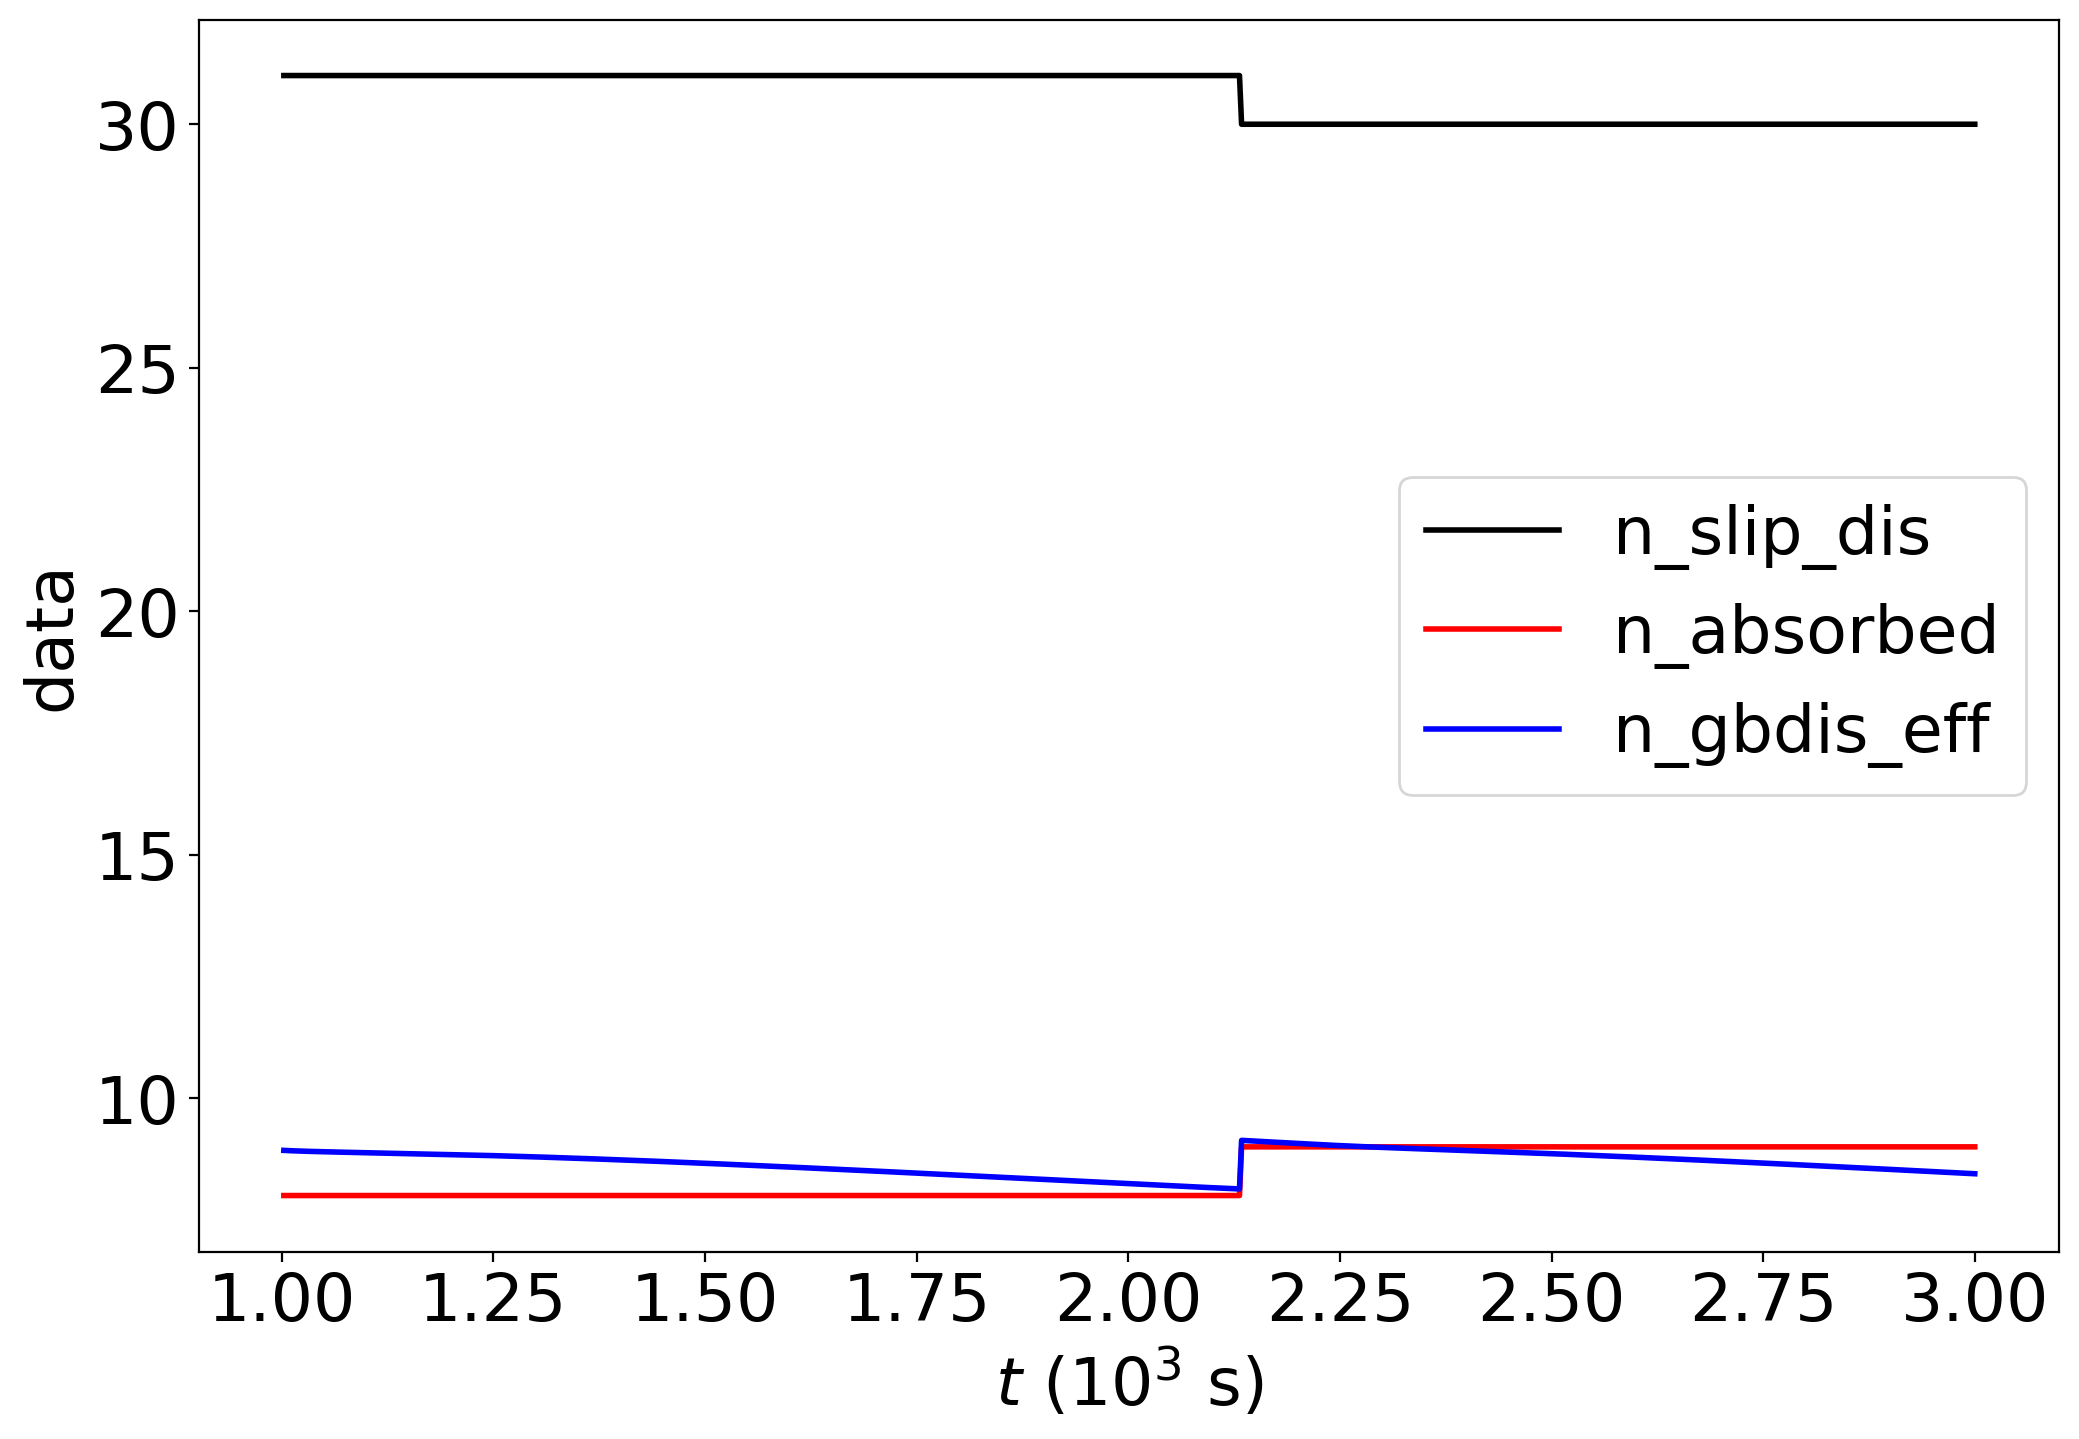

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.4479916990903814e-13, Nslip: 30.0, Ngb_eff: 8.557381899745062
Data file with H=10.0, L=0.1, T=900.0, tau0=50.0, n=24


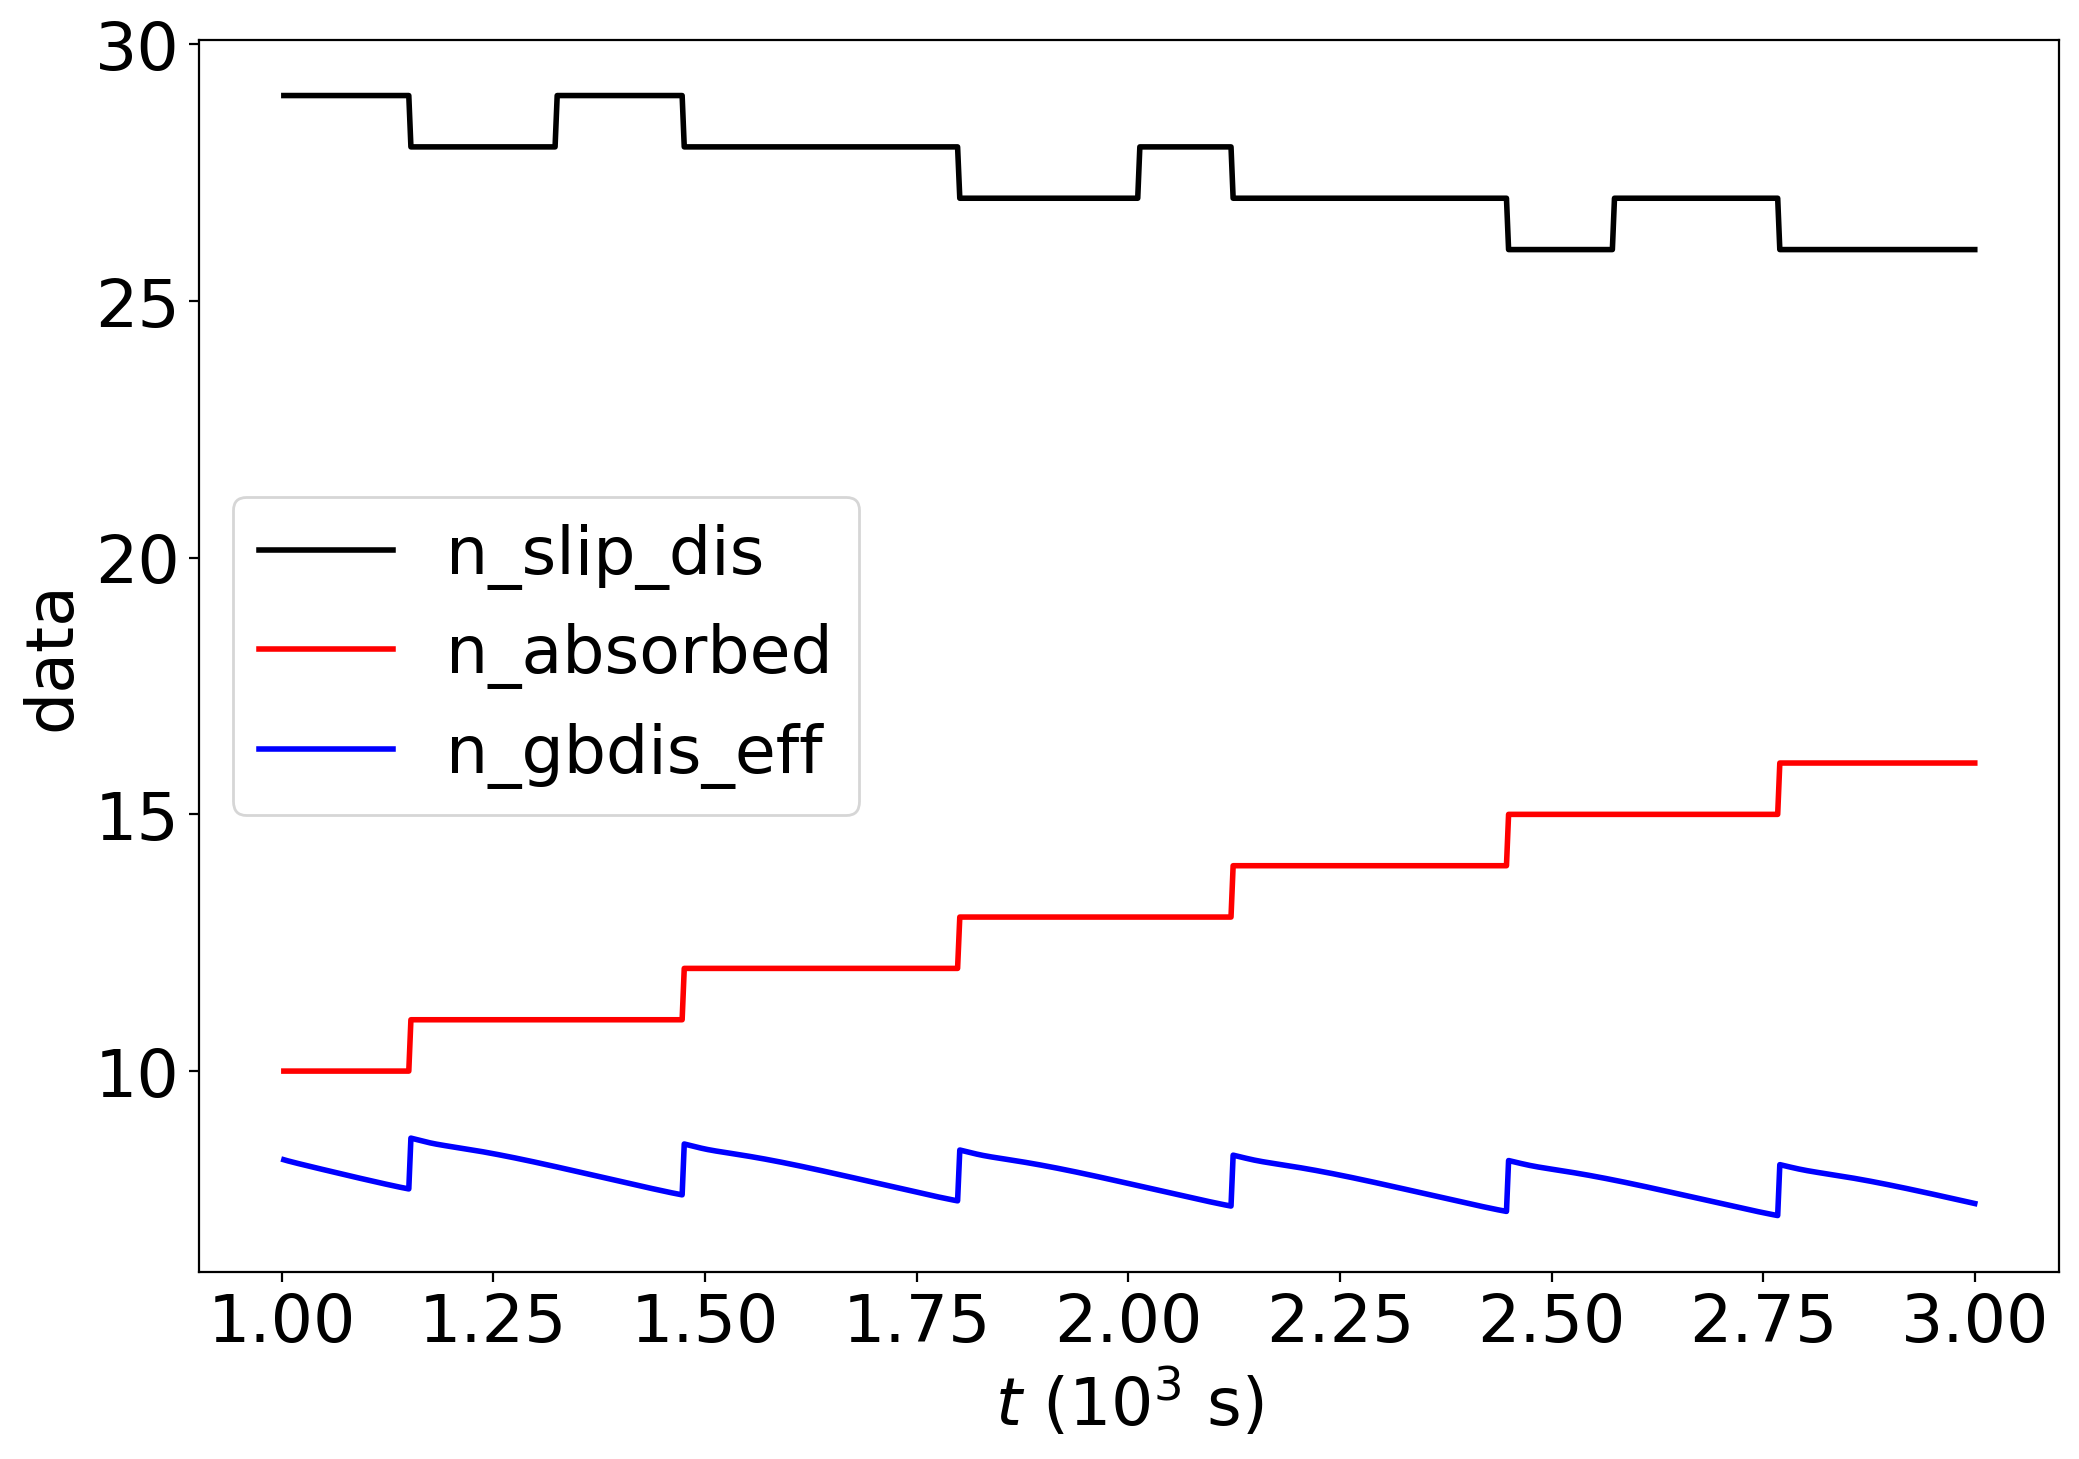

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 4.454553908915658e-12, Nslip: 26.07, Ngb_eff: 7.770589880935298
Data file with H=10.0, L=0.1, T=1000.0, tau0=75.0, n=24


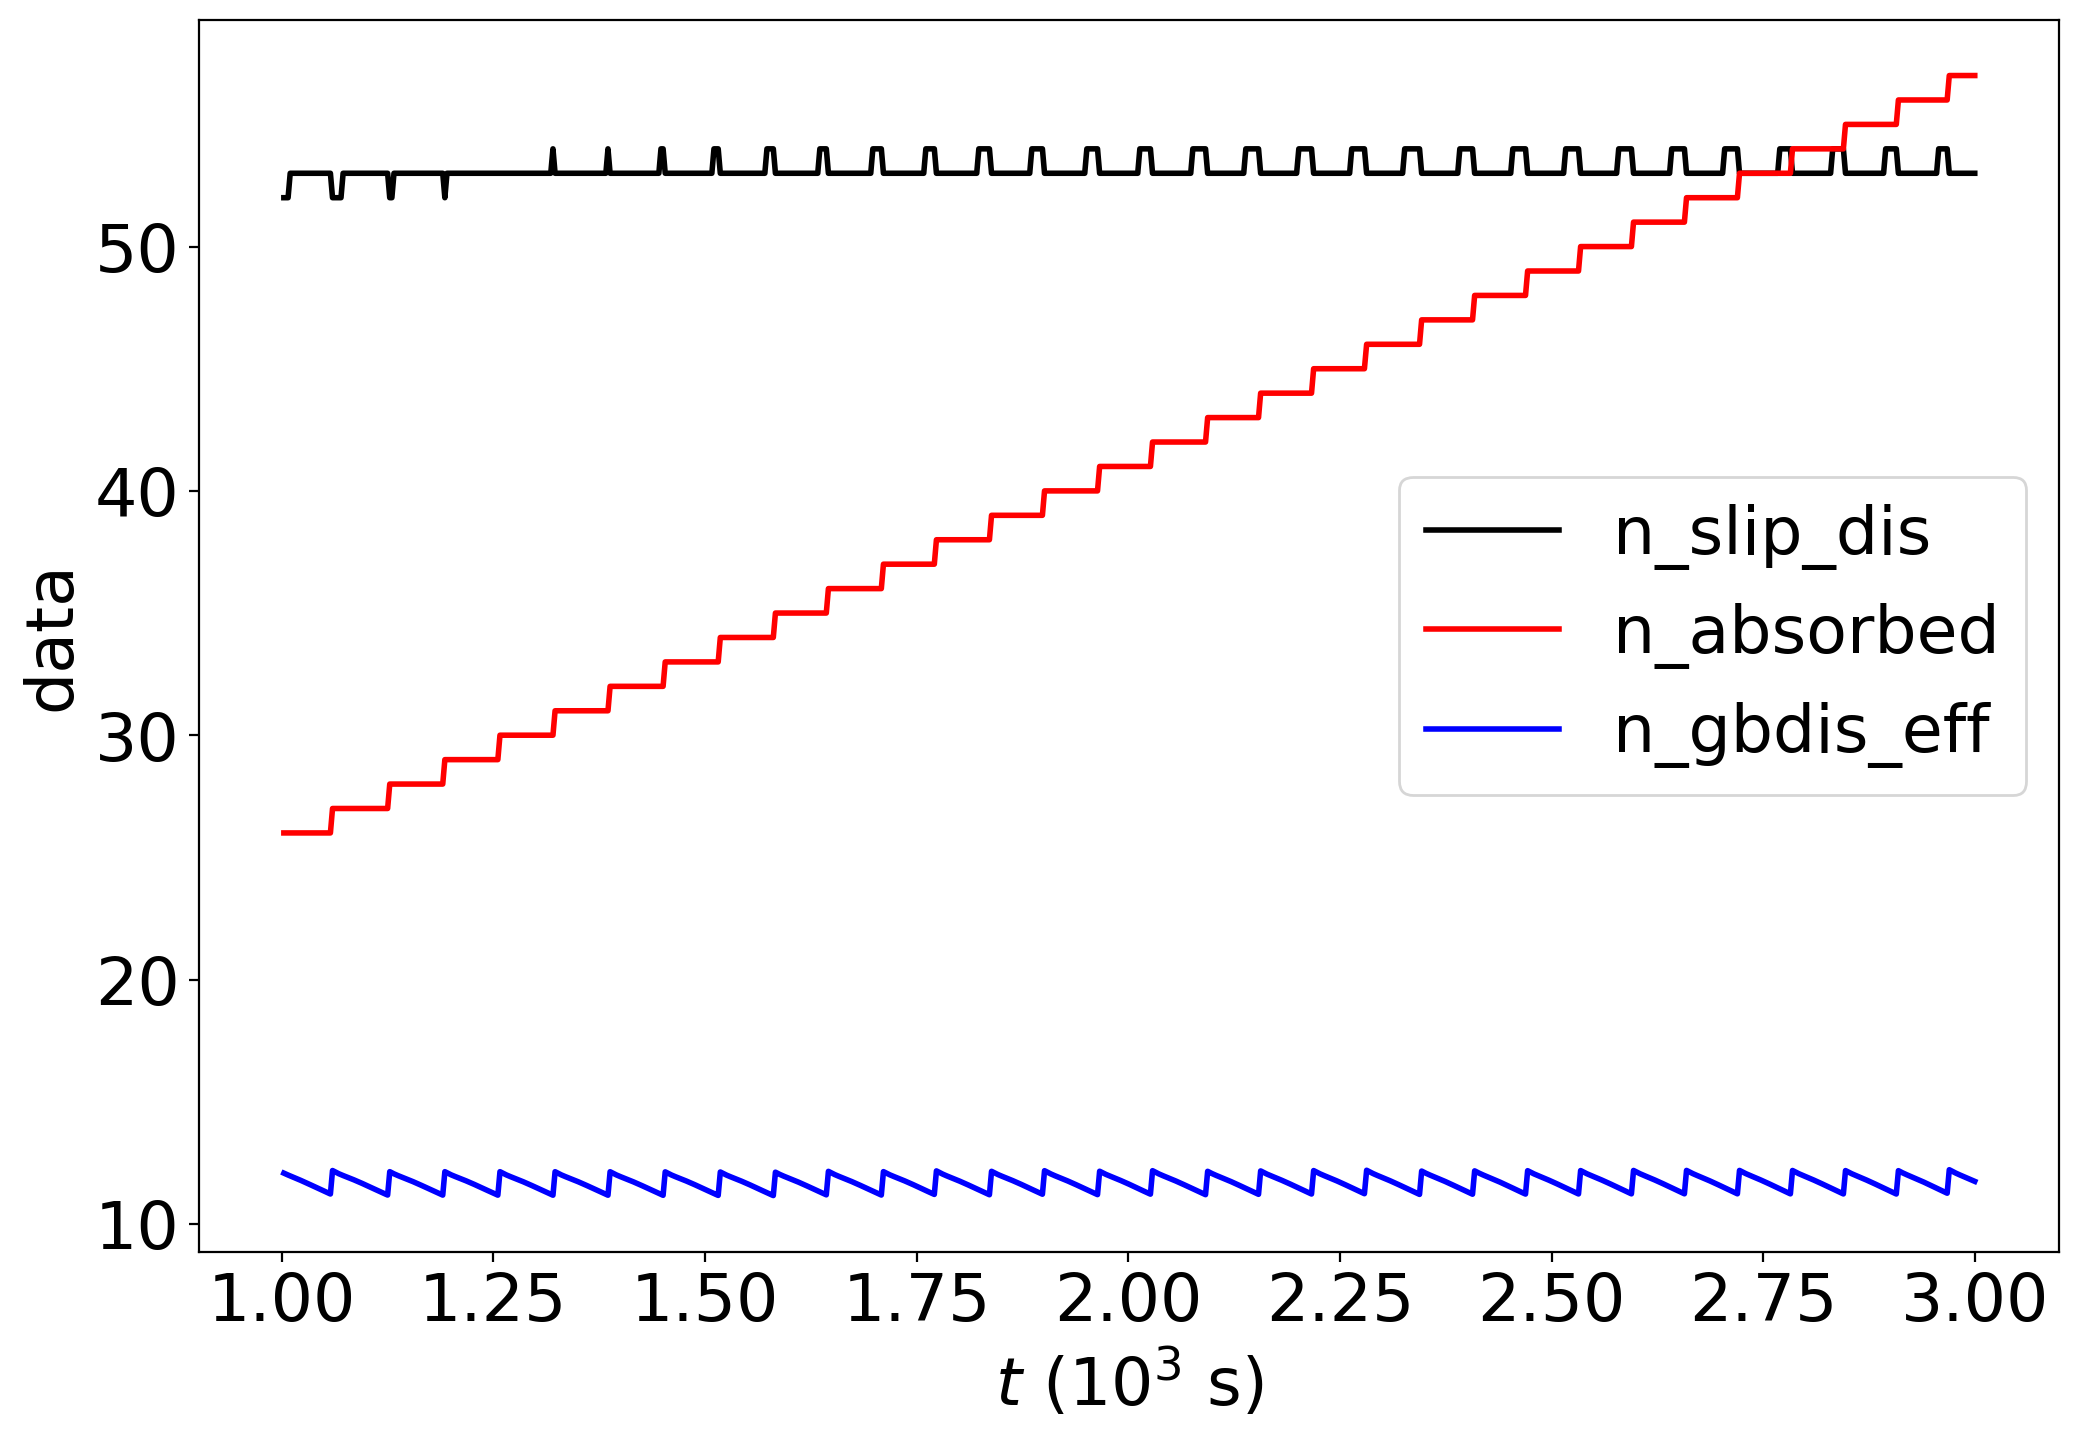

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 3.972658143630288e-11, Nslip: 53.23, Ngb_eff: 11.7119701691119
Data file with H=10.0, L=0.1, T=800.0, tau0=75.0, n=24


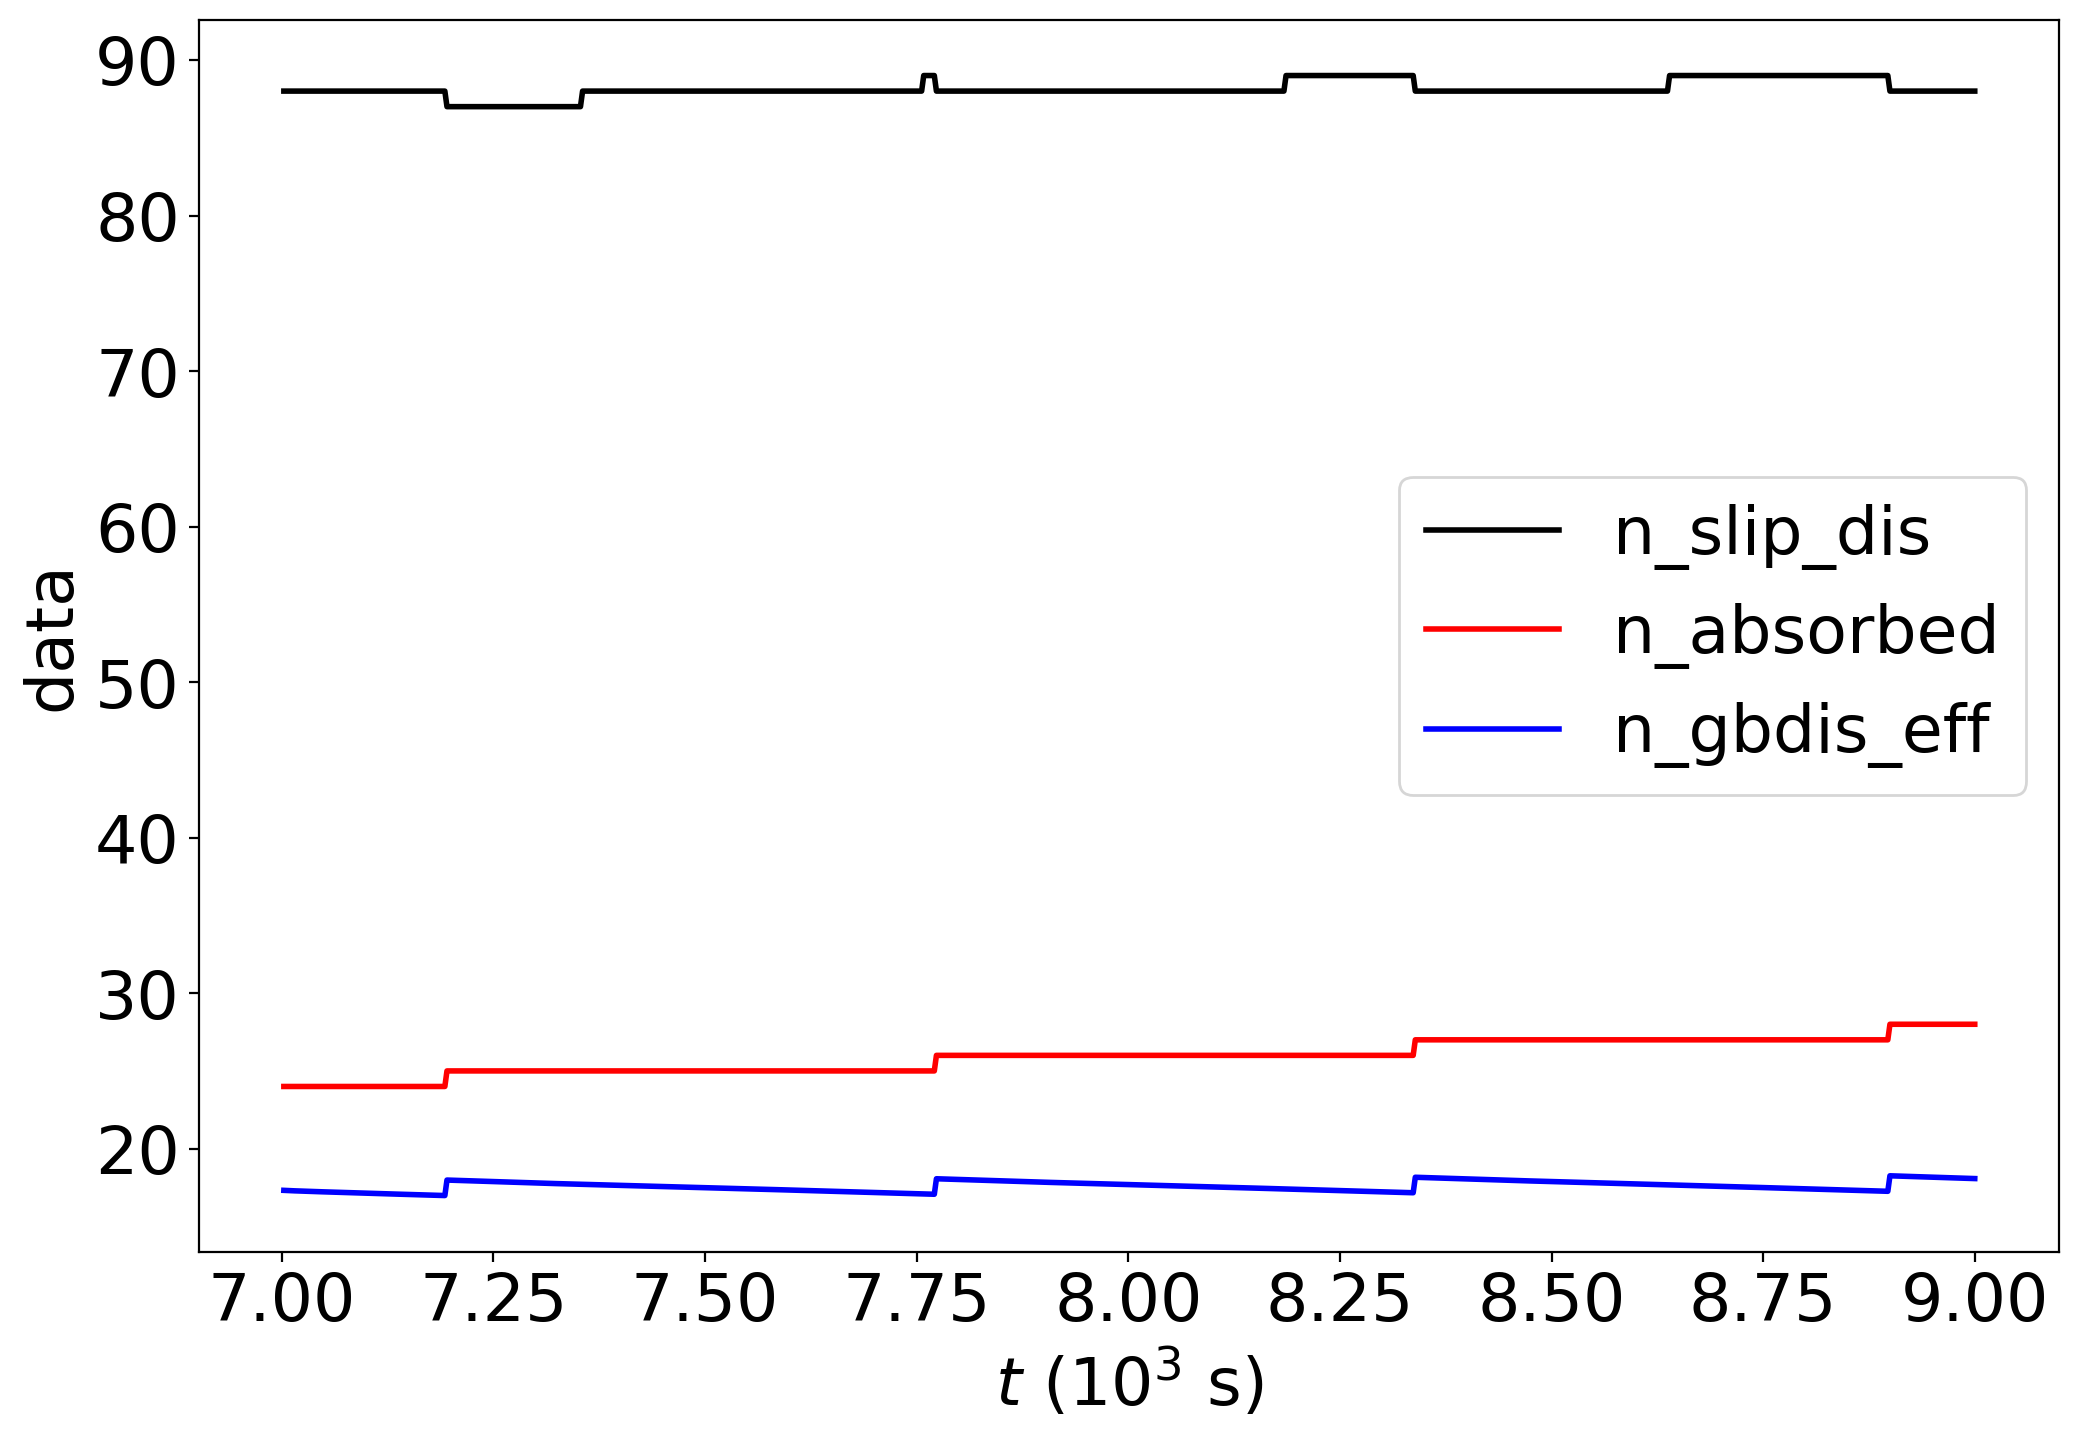

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 5.140946655789192e-12, Nslip: 88.59, Ngb_eff: 17.70182787054508
Data file with H=10.0, L=0.1, T=900.0, tau0=75.0, n=24


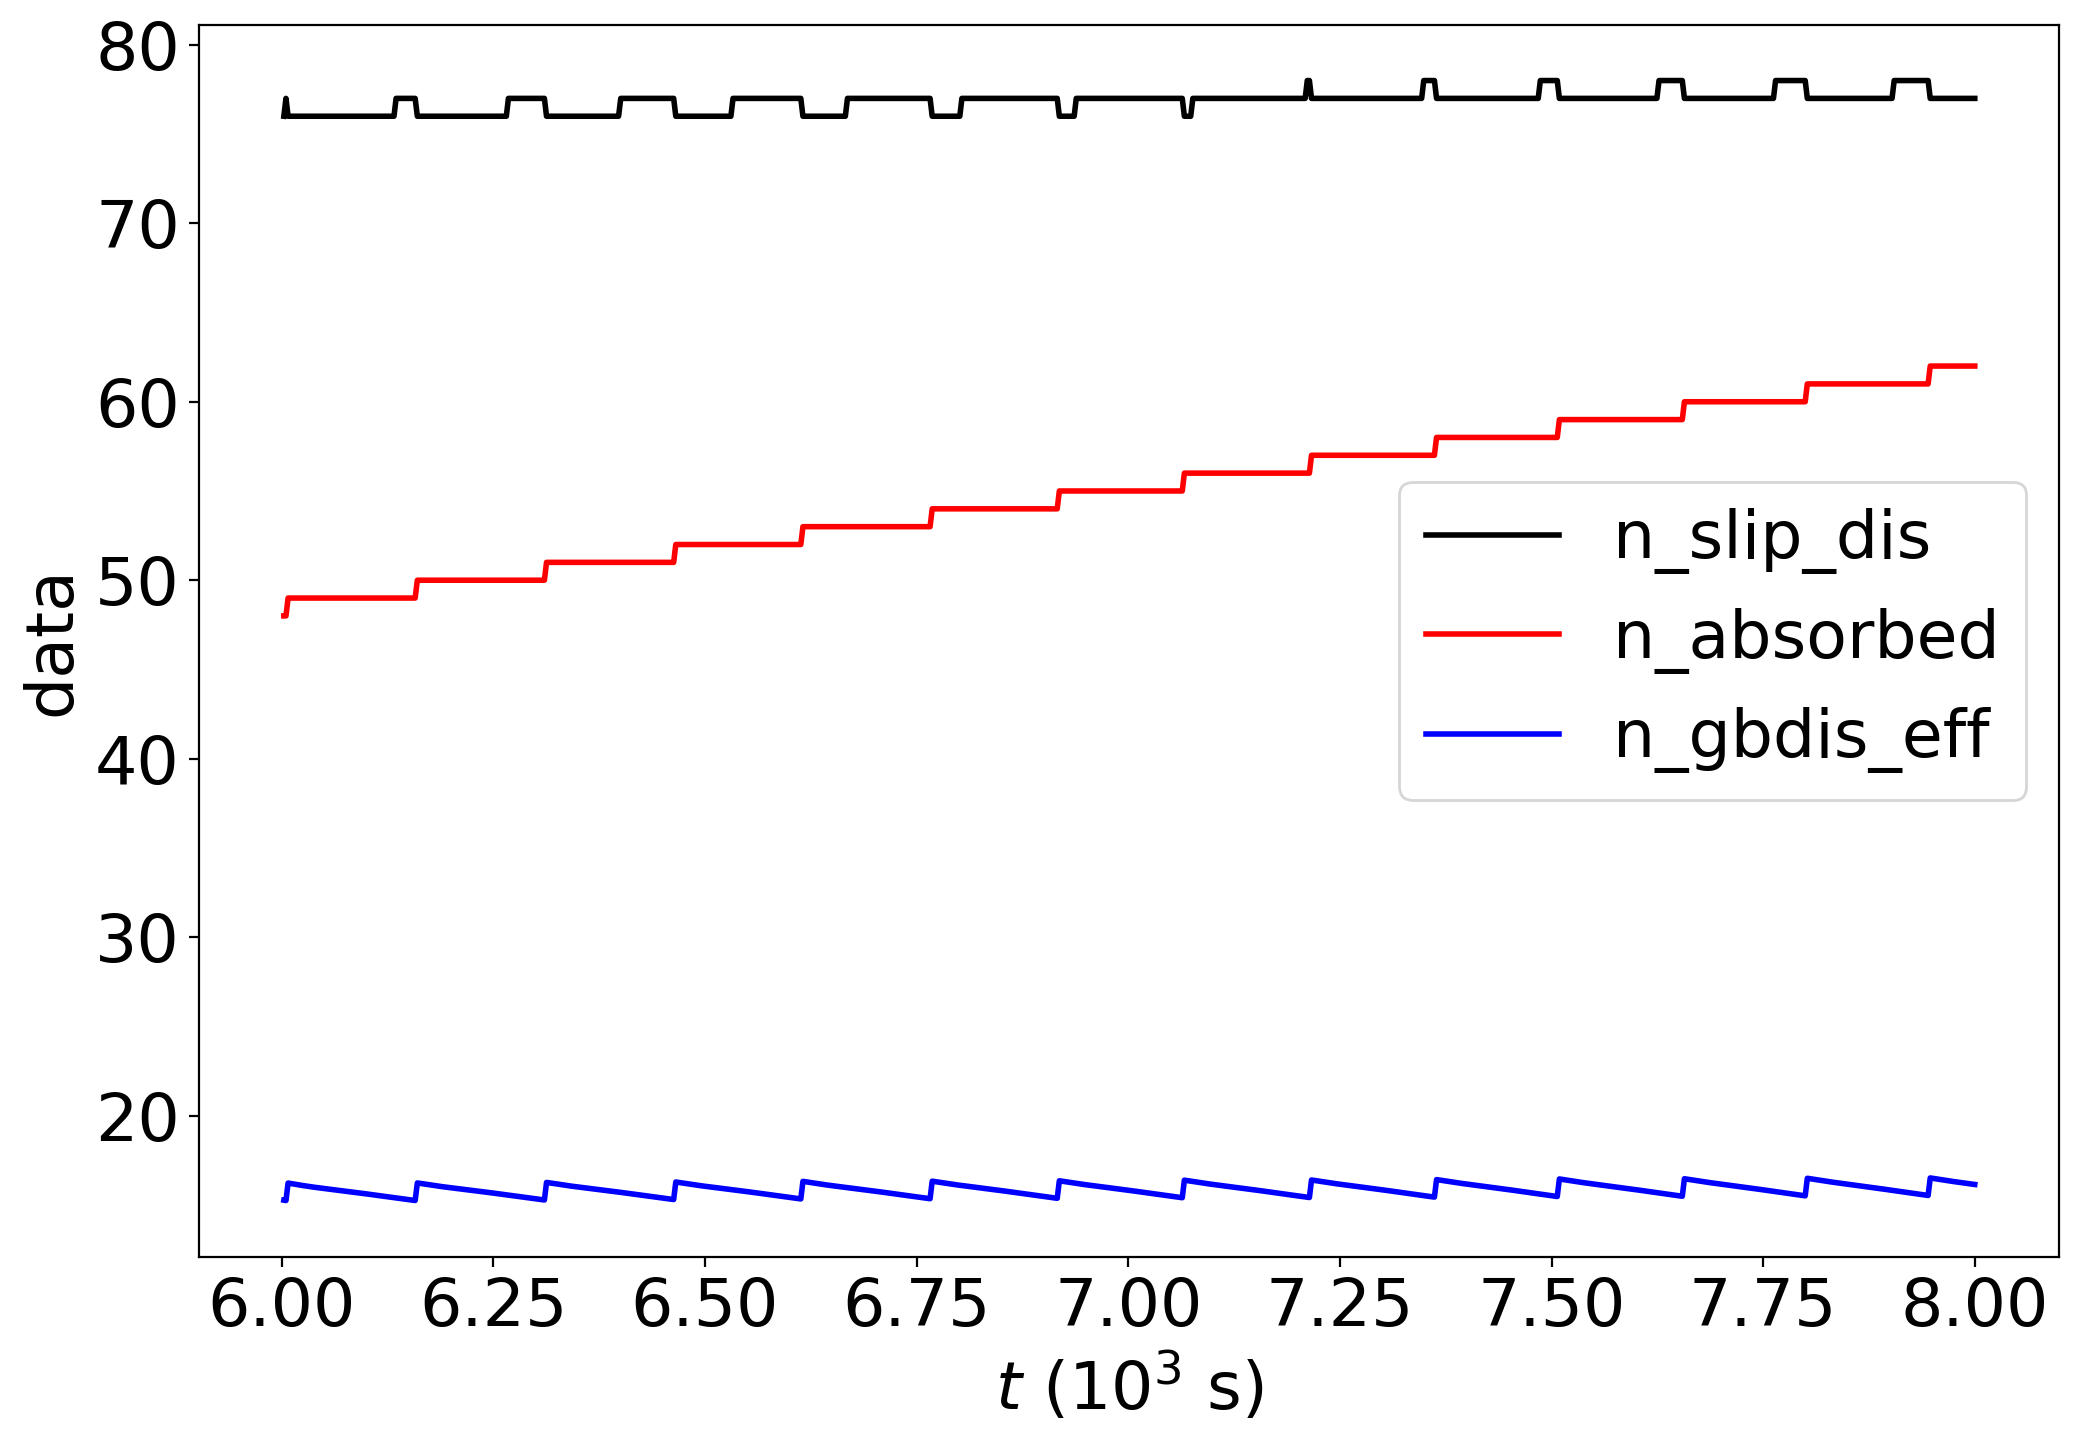

** Max. time step = 2441.406249999999, Median: 2441.406249999999
Av. slip rate: 1.7897362620206973e-11, Nslip: 77.32, Ngb_eff: 16.001095024216177


In [2]:
path = "../data/Res-tau_var/"
flist = find_h5_files(path)
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file=fname)
    print(f"Data file with H={gbdd.D2}, L={gbdd.Dgp}, T={gbdd.temp}, tau0={gbdd.tau0}, n={gbdd.Ngbn-1}")
    gbdd.plot_time_series(['n_slip_dis', 'n_absorbed', 'n_gbdis_eff'])
    print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    print(f"Av. slip rate: {np.mean(gbdd.glob_data['plast_slip_rate'][-100:])}, "
          f"Nslip: {np.mean(gbdd.glob_data['n_slip_dis'][-100:])}, Ngb_eff: {np.mean(gbdd.glob_data['n_gbdis_eff'][-100:])}")
    data.append(gbdd)

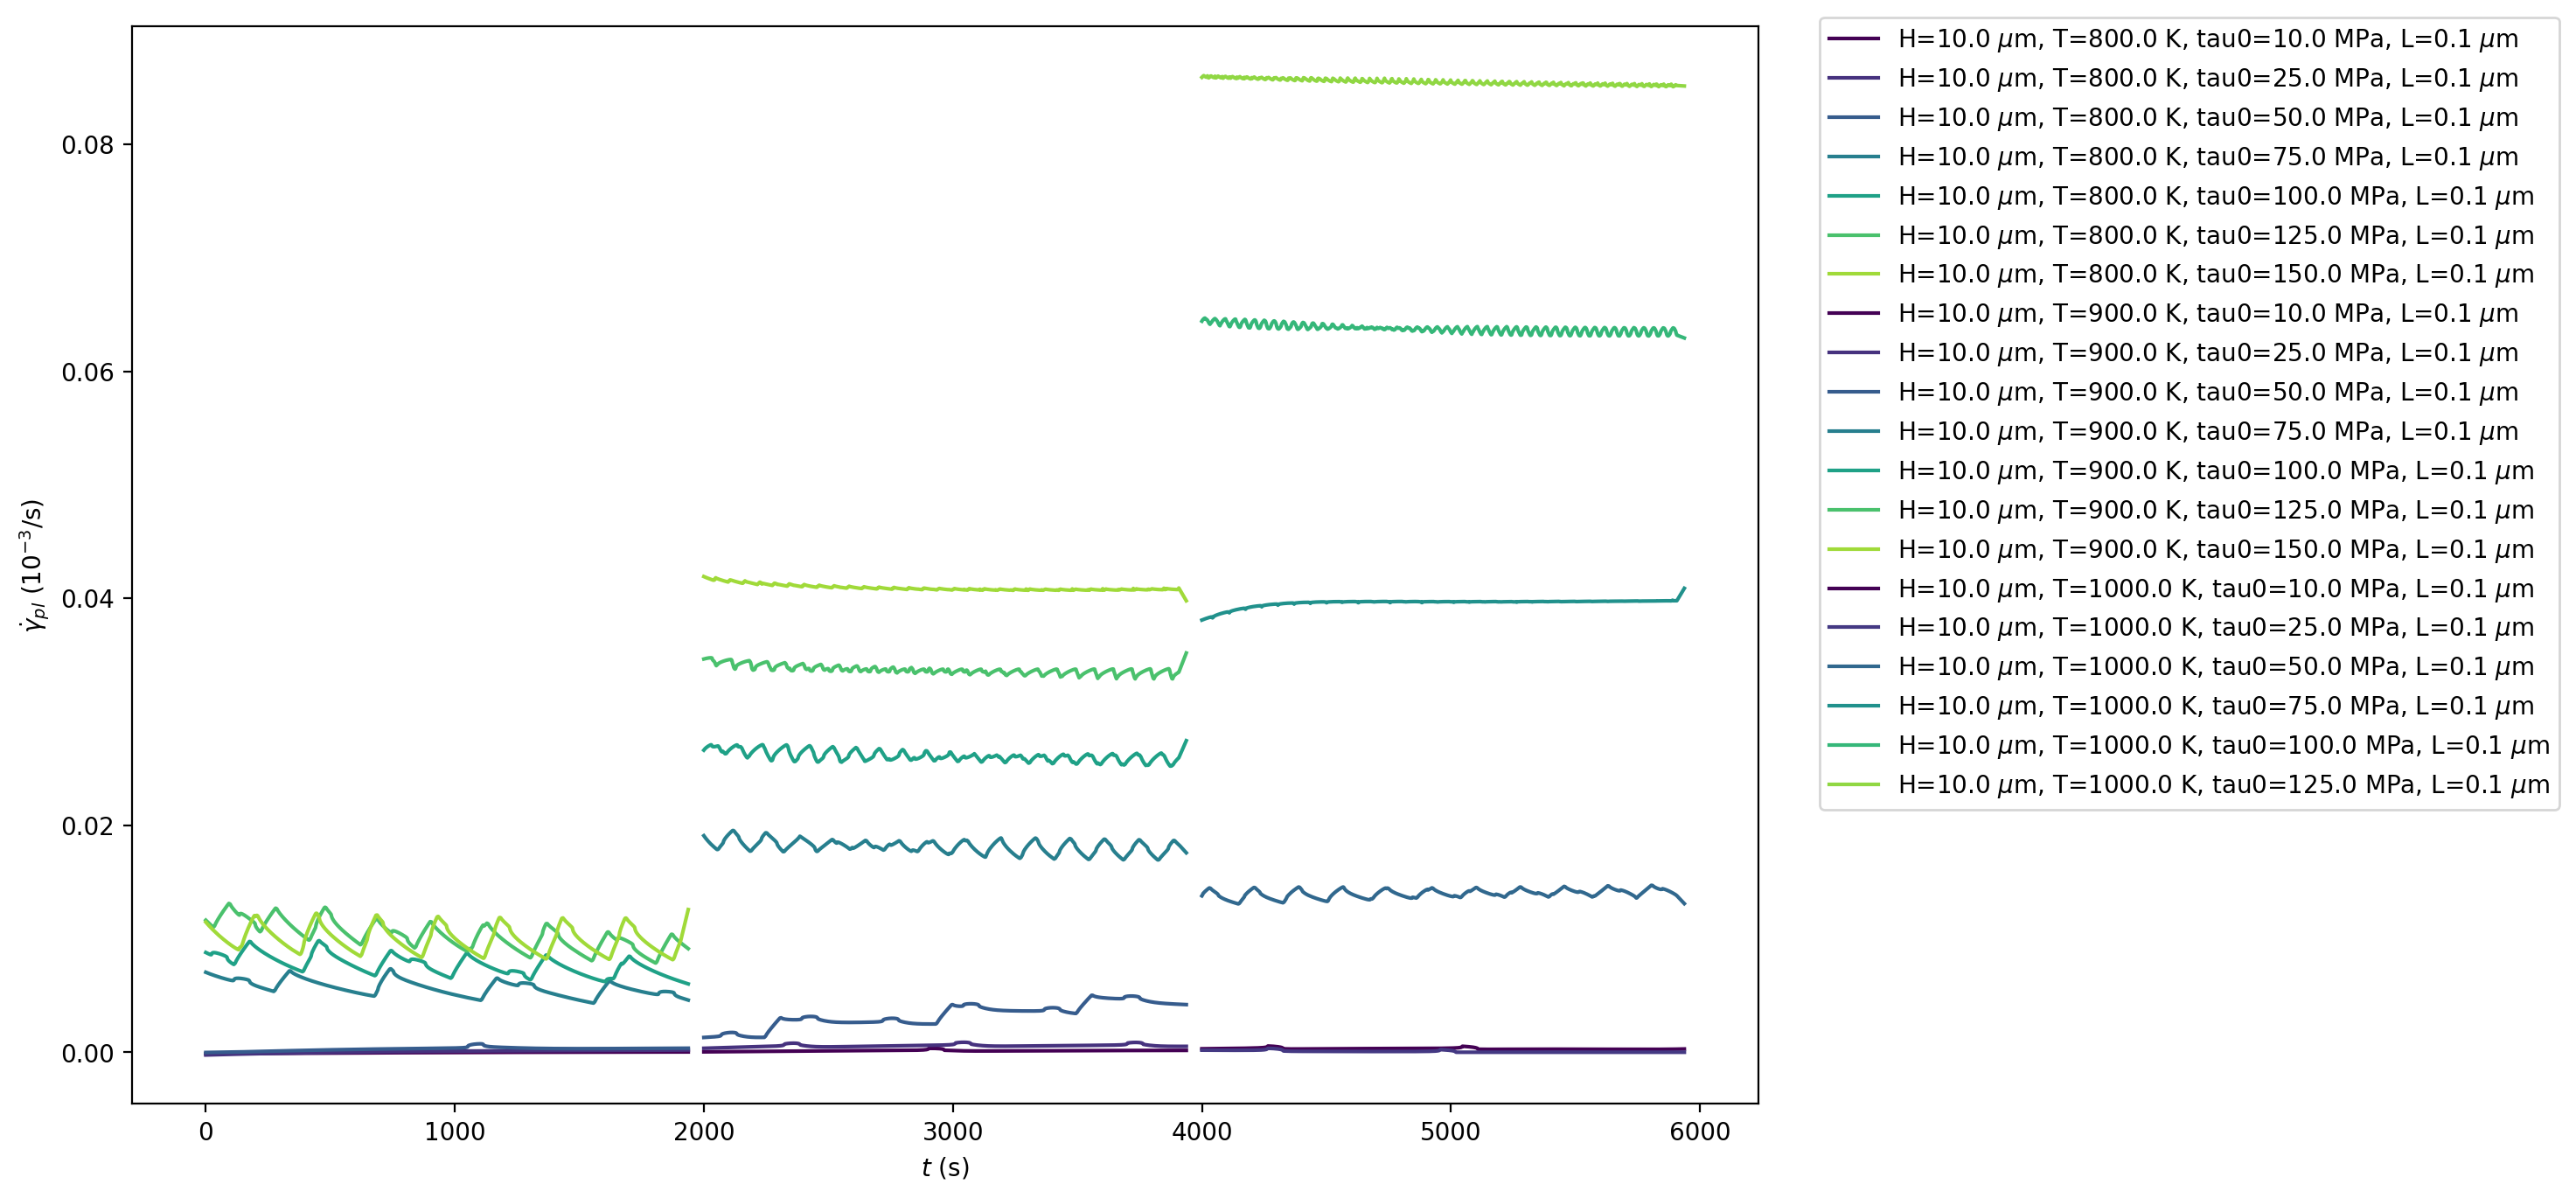

In [16]:
#store data in nd-arrays
num = len(data)
psr_ = np.zeros(num)
temp_ = np.zeros(num)
gs_ = np.zeros(num)
H_ = np.zeros(num)
L_ = np.zeros(num)
tau_ = np.zeros(num)
nit = np.zeros(num, dtype=int)
psr_flt = np.zeros((num, maxout))
stime = np.zeros((num, maxout))

hh_ = np.zeros(num)
for i, ds in enumerate(data):
    hh_[i] = ds.tau0
isort = np.argsort(hh_)

for i, j in enumerate(isort):
    ds = data[j]
    nit[i] = ds.nout
    stime[i, :nit[i]] = ds.sim_time
    gs_[i] = ds.D2
    temp_[i] = ds.temp
    H_[i] = ds.D2
    L_[i] = ds.Dgp
    tau_[i] = ds.tau0
    #gplast = ds.glob_data['plastic_slip']
    psr_[i] = np.mean(ds.glob_data['plast_slip_rate'][ds.nout//10:-5])
    wl = min(25, int(ds.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {ds.nout}")
        psr_flt[i, :nit[i]] = ds.glob_data['psr_av']
    else:
        psr_flt[i, :nit[i]-5] = savgol_filter(ds.glob_data['psr_av'][:-5], window_length=wl, polyorder=1, deriv=0)

plt.rcParams["font.size"] = 10
ioffs=20
tapp = [800, 900, 1000]
hfac = lambda x: np.log(x/min(H_)) / np.log(max(H_)/min(H_))
ngbl = 0.1
cmap = plt.cm.viridis  #plasma
plfun = plt.plot  # semilogy
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for k, t in enumerate(tapp):
    ind = np.nonzero(np.logical_and(np.isclose(temp_, t), np.isclose(L_, ngbl)))[0]
    for j, i in enumerate(ind):
        cx = j/len(ind)
        col = cmap(cx)
        xval = stime[i, ioffs:nit[i]-5] - stime[i, ioffs]
        plfun(xval*1.e-6 + 2000*k,
             psr_flt[i, ioffs:nit[i]-5]*1.e9,
             marker="none",
             linestyle="solid",
             color=col,
             label=f"H={gs_[i]}"+r" $\mu$m, " + f"T={temp_[i]} K, tau0={tau_[i]} MPa, L={L_[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()



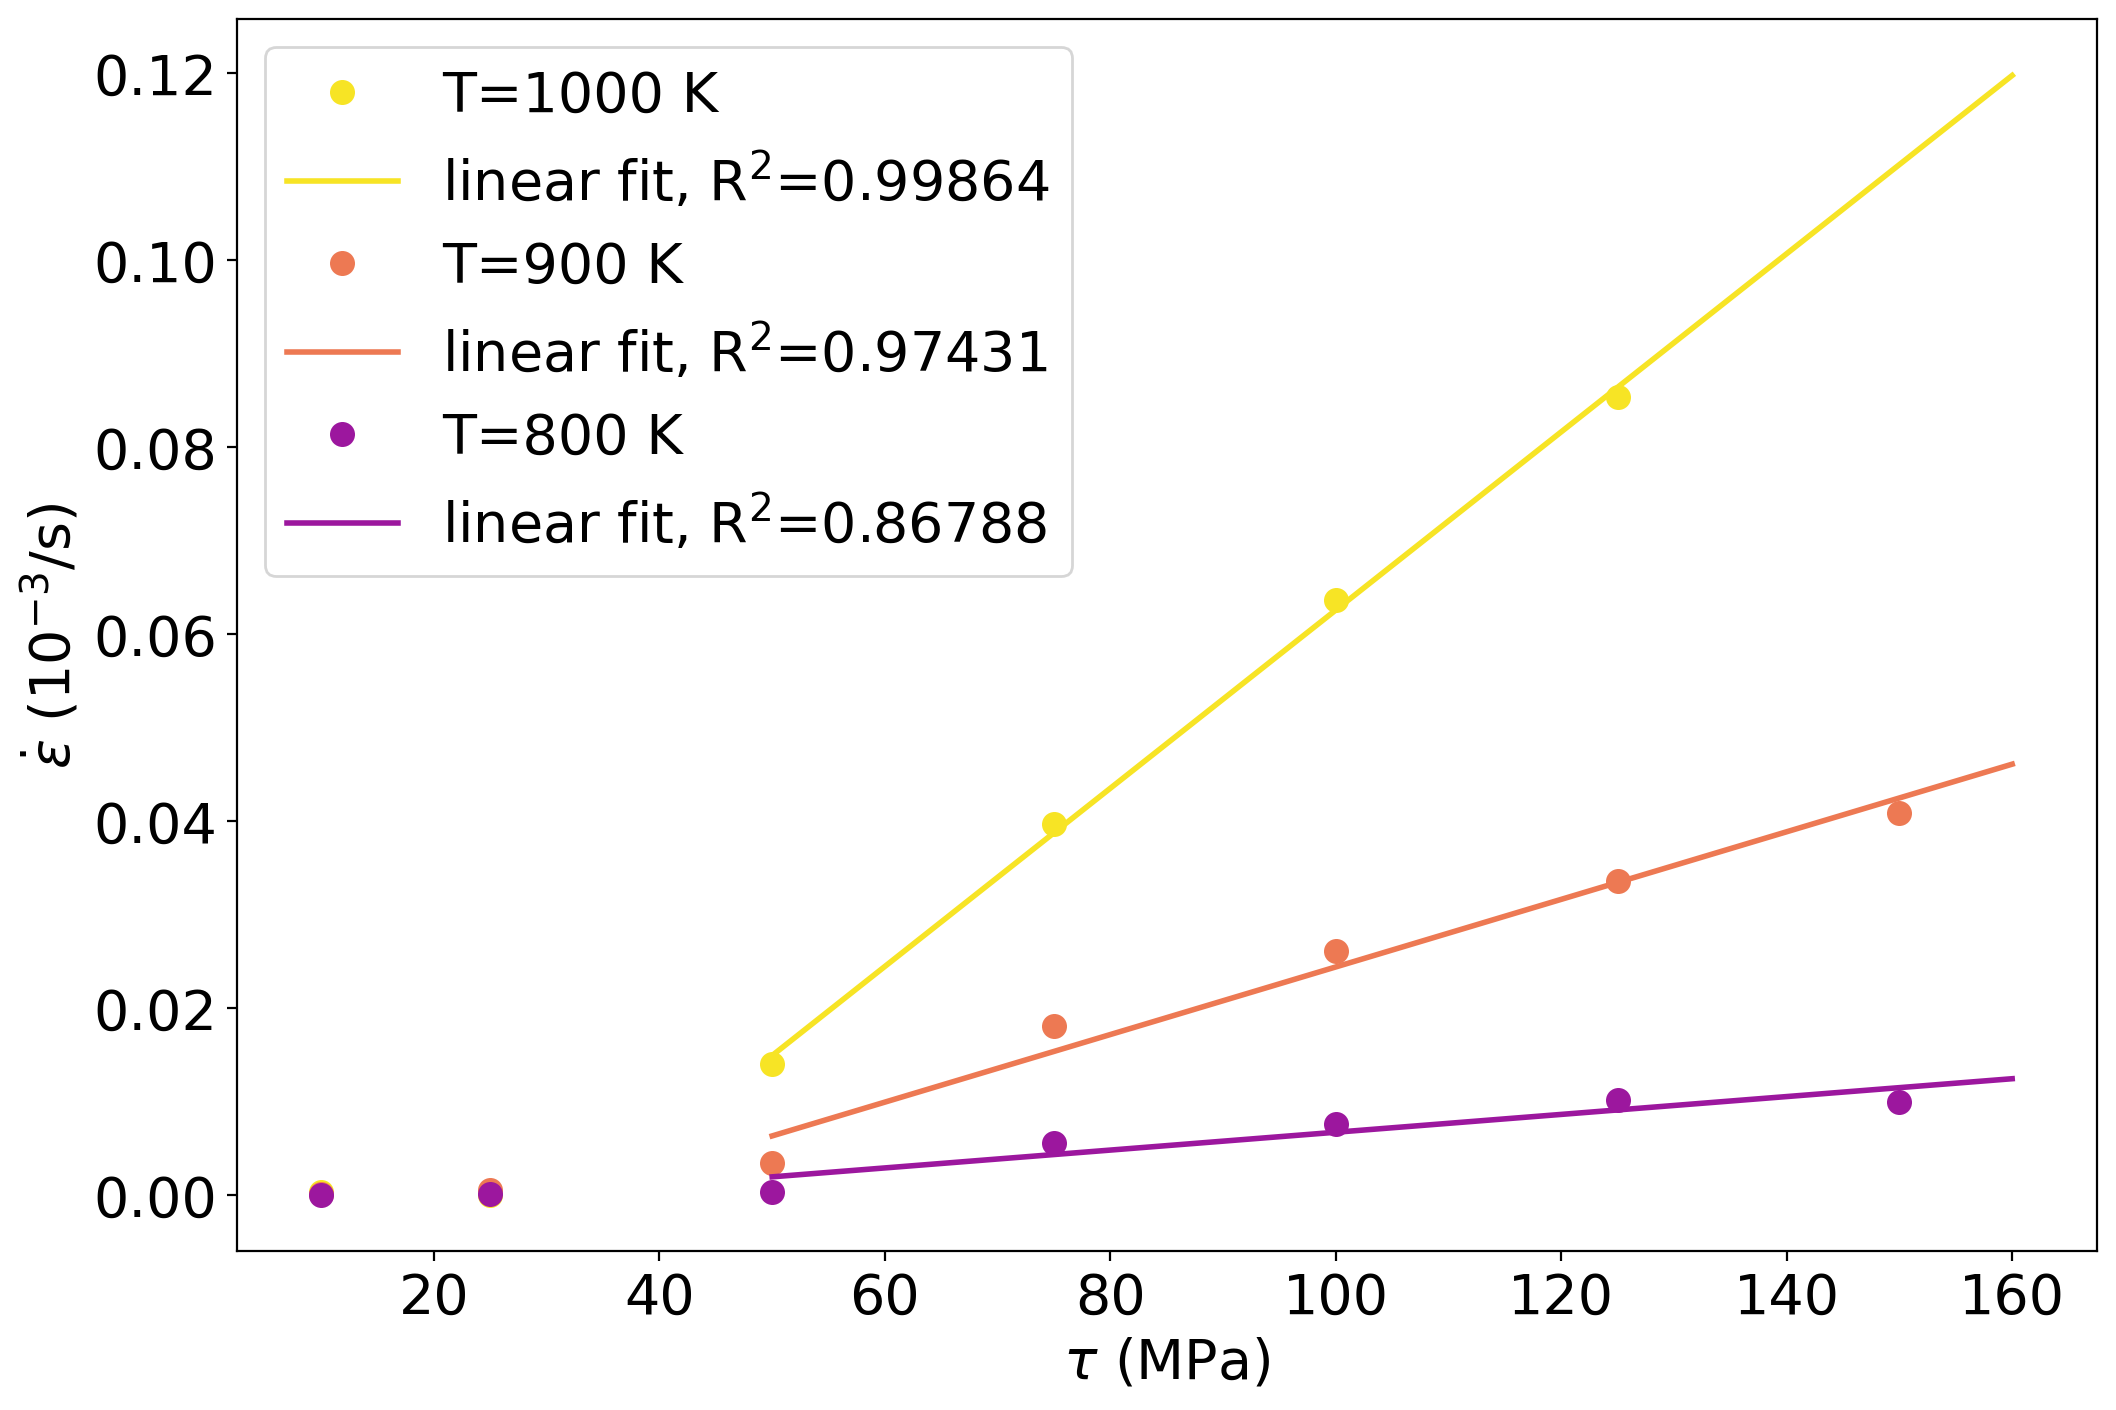

In [20]:
plt.rcParams["font.size"] = 20
lw = 2
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

xv = np.linspace(50, 160, 50)
tau = np.zeros((3, 7))
cr = np.zeros((3, 7))
cmap = plt.cm.plasma

ind = np.nonzero(np.logical_and(np.isclose(temp_, 1000.), np.isclose(L_, 0.1)))[0]
assert len(ind) == 6
tau[2, :6] = tau_[ind].copy()
cr[2, :6] = psr_[ind].copy()*1.e9
res10 = linregress(tau[2, 2:6], cr[2, 2:6], alternative="greater")
yv10 = res10.intercept + res10.slope*xv
ind = np.nonzero(np.logical_and(np.isclose(temp_, 900.), np.isclose(L_, 0.1)))[0]
assert len(ind) == 7
tau[1, :] = tau_[ind].copy()
cr[1, :] = psr_[ind].copy()*1.e9
res9 = linregress(tau[1, 2:], cr[1, 2:], alternative="greater")
yv9 = res9.intercept + res9.slope*xv
ind = np.nonzero(np.logical_and(np.isclose(temp_, 800.), np.isclose(L_, 0.1)))[0]
assert len(ind) == 7
tau[0, :] = tau_[ind].copy()
cr[0, :] = psr_[ind].copy()*1.e9
res8 = linregress(tau[0, 2:], cr[0, 2:], alternative="greater")
yv8 = res8.intercept + res8.slope*xv
col = cmap(0.95)
plt.plot(tau[2,:6], cr[2,:6],
         color = col,
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=1000 K")
plt.plot(xv, yv10, 
         linestyle = "solid",
         linewidth = lw,
         color = col, 
         label=r'linear fit, R$^2$' + f'={res10.rvalue**2:.5f}')
col = cmap(0.667)
plt.plot(tau[1,:], cr[1,:],
         color = col,
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=900 K")
plt.plot(xv, yv9,
         linestyle = "solid",
         linewidth = lw,
         color = col,
         label=r'linear fit, R$^2$' + f'={res9.rvalue**2:.5f}')
col = cmap(0.333)
plt.plot(tau[0,:], cr[0,:],
         color = col,
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=800 K")
plt.plot(xv, yv8,
         linestyle = "solid",
         linewidth = lw,
         color = col,
         label=r'linear fit, R$^2$' + f'={res8.rvalue**2:.5f}')
plt.xlabel(r"$\tau$ (MPa)")
plt.ylabel(r"$\dot\varepsilon$ (10$^{-3}$/s)")
plt.legend(loc='upper left')
plt.savefig("creep_tau.pdf", dpi=300)
plt.show()

In [32]:
Qact = data[0].Qact
R = 8.31446
slope_ = np.array([res7.slope, res8.slope, res9.slope])
print(slope_)
arrh_ = np.array([
    np.exp(-Qact / (R*700)),
    np.exp(-Qact / (R*800)),
    np.exp(-Qact / (R*900)),
])
print(slope_ / arrh_)

[0.00028994 0.00080233 0.00171814]
[5.19536157 4.22669764 3.4929193 ]


In [26]:
arrh_

array([5.58071178e-05, 1.89824994e-04, 4.91891915e-04])

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
#xval = 1./np.sqrt(gs_list)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xlabel = r"$H$ ($\mu$m)"
for i, ds in enumerate(data):
    plt.plot(ds.D2, ds.npu_max,
             color=plt.cm.viridis(ds.temp/900.),
             linestyle = "none",
             marker = 'o',
             #label=f"T={ds.temp} K"
            )
xv = np.linspace(0, 40, 50)
ds = data[0]
hc = np.pi*(1. - ds.nu)/(ds.mu*ds.B)*ds.tau0
yv = hc * xv
plt.plot(xv, yv, '-k')
plt.xlabel(xlabel)
plt.ylabel("max(N_dis)")
plt.legend()
plt.show()

In [ ]:
# set simulation parameters
temp = 900.0
tau0 = 150.0
lgb = 0.1
delta = 0.004
ngbn = int(lgb/delta)
if ngbn % 2 == 0: ngbn += 1
dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
#grain_size = 1.0
tfin = 1.5e9
niter = 500_000_000

# set variable quantity
D2_list = [1]
Np = len(D2_list)

# initialize arrays to store results
psr_av = np.zeros((Np, maxout))
gplast = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
gs_list = np.zeros(Np)

# run simulations
for i, gs in enumerate(D2_list):
    print(f"Simulation with N_gbn={ngbn}, grain_size={gs}, dtmax={dtmax}")
    gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                       Ngbn=ngbn, len_gb_seg=lgb, grain_size=gs,
                       tfin=tfin, niter=niter, maxout=maxout,
                       dtmax=dtmax,
                       screenout=True)
    gbdd.run_sim()
    gbdd.save_hdf5(f"pu1_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.h5")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    #gbdd.plot_time_series('plastic_slip', fs=26, lw=3)
    gbdd.plot_time_series('psr_av', fs=26, lw=4,
                          file=f"pu1_gd_tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('displacement', fs=26, lw=4, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    gbdd.plot_field('bfield', fs=26, lw=3, nplot=6,
                    file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf")
    nit[i] = gbdd.nout
    gs_list[i] = gs
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
    psr_list[i] = np.mean(gbdd.glob_data['plast_slip_rate'][-100:])


In [ ]:
# read existing data from GDF5 files
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file=path+fname+".h5")
    print(f"Data file with D={gbdd.D2}, delta={gbdd.Dgp}, dtmax={gbdd.dtmax}")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    #gbdd.plot_time_series('max_bdot')
    #gbdd.plot_time_series('plast_slip_rate')
    gbdd.plot_time_series('psr_av')
    #gbdd.plot_field('displacement')
    gbdd.plot_field('bfield')
    nit[i] = gbdd.nout
    gs_list[i] = gbdd.D2
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    wl = min(25, int(gbdd.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {gbdd.nout}")
        psr_av[i, 0:gbdd.nout] = gbdd.glob_data['psr_av']
    else:
        psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=wl, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
    psr_list[2, i] = np.mean(gbdd.glob_data['plast_slip_rate'][-100:])
    temp_list[2] = 500.
                          

In [ ]:
plt.rcParams["font.size"] = 20

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.plot(sim_time[i, :nit[i]-20]*1.e-6,
             psr_av[i, :nit[i]-20]*1.e9,
             marker="none",
             linestyle="-",
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"D={gs_list[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
#xval = 1./np.sqrt(gs_list)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xval = gs_list
xlabel = r"$H$ ($\mu$m)"
plt.plot(xval, psr_list[0,:-1]*1.e9,
         color='red',
        label=f"T=900 K")
plt.plot(xval, psr_list[1,:-1]*1.e9,
         color='orange',
        label=f"T=700 K")
plt.plot(xval, psr_list[2,:-1]*1.e9,
         color='blue',
        label=f"T=500 K")
plt.xlabel(xlabel)
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
plt.legend()
plt.show()

In [ ]:
psr_list

In [ ]:
gbdd.plot_pile_up()
gbdd.plot_time_series('n_slip_dis')

In [ ]:
it = 500
plt.rcParams["font.size"] = 12
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(file=f"sigpu_tau{int(gbdd.tau0)}_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf", cutoff=200)


In [ ]:

gbdd.Dgp